# Programming Assignment 1 — Segmentação de Instâncias

In [16]:
import os
import sys
import time
import utils
import torch
import numpy as np

sys.path.append(os.path.abspath('src'))

device = utils.get_device()
print(f"Dispositivo: {device}")

Dispositivo: mps


In [17]:
# Modelo: U-Net ResNet18
model_test = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
print(f"Modelo carregado. Output: {tuple(model_test(dummy_in).shape)}")

Modelo carregado. Output: (2, 1, 128, 128)


--- 
## Parte 0 — Teste Unitário Sintético

In [18]:
# Parte 0 — Dataset Sintético (670 imagens 128x128)
images_synth, masks_synth = utils.gerar_dataset_elipses(num_images=670, image_size=(128, 128), num_ellipses_range=(5, 20), seed=42)
X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s = utils.split_dataset(images_synth, masks_synth, seed=42, stratify=False)
print(f"Dataset Sintético | Treino: {X_tr_s.shape[0]} | Val: {X_v_s.shape[0]} | Teste: {X_te_s.shape[0]}")

Dataset Sintético | Treino: 468 | Val: 101 | Teste: 101


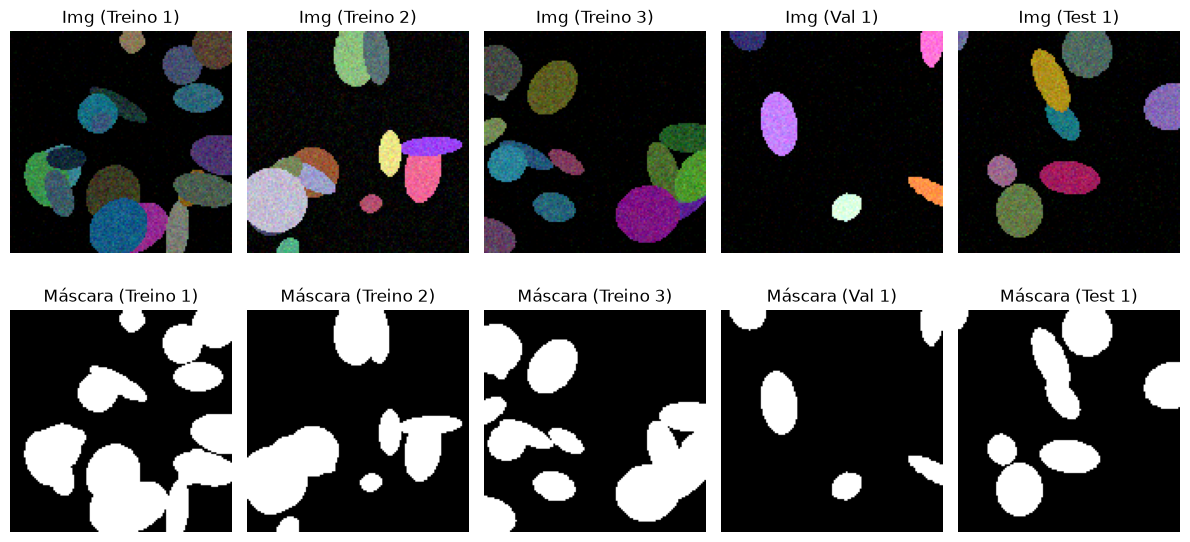

In [19]:
# Parte 0 — Visualização de Amostras Sintéticas
utils.plot_dataset_samples(X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s)

In [20]:
# Parte 0 — Treinamento ResUNet
model_synth = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
t0 = time.time()
utils.train_model(model_synth, X_tr_s, y_tr_s, X_v_s, y_v_s, device, num_epochs=10, batch_size=8)
t1 = time.time()
print(f"Treinamento concluído em {t1 - t0:.2f} segundos.")

Epoch [ 1/10] | Train Loss: 0.2601 | Val Loss: 0.1658
Epoch [ 2/10] | Train Loss: 0.1054 | Val Loss: 0.0714
Epoch [ 3/10] | Train Loss: 0.0512 | Val Loss: 0.0374
Epoch [ 4/10] | Train Loss: 0.0291 | Val Loss: 0.0225
Epoch [ 5/10] | Train Loss: 0.0186 | Val Loss: 0.0152
Epoch [ 6/10] | Train Loss: 0.0129 | Val Loss: 0.0109
Epoch [ 7/10] | Train Loss: 0.0095 | Val Loss: 0.0078
Epoch [ 8/10] | Train Loss: 0.0072 | Val Loss: 0.0060
Epoch [ 9/10] | Train Loss: 0.0057 | Val Loss: 0.0048
Epoch [10/10] | Train Loss: 0.0046 | Val Loss: 0.0039
Treinamento concluído em 38.59 segundos.


In [21]:
# Parte 0 — Avaliação Semântica (Dice & IoU)
dice_s, iou_s = utils.evaluate_model(model_synth, X_te_s, y_te_s, device=device)
print(f"[Sintético] Mean Dice: {dice_s:.4f} | Mean IoU: {iou_s:.4f}")

[Sintético] Mean Dice: 1.0000 | Mean IoU: 1.0000


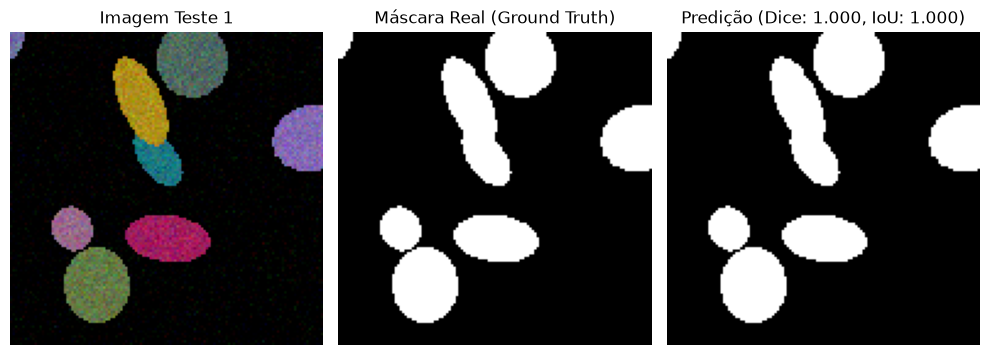

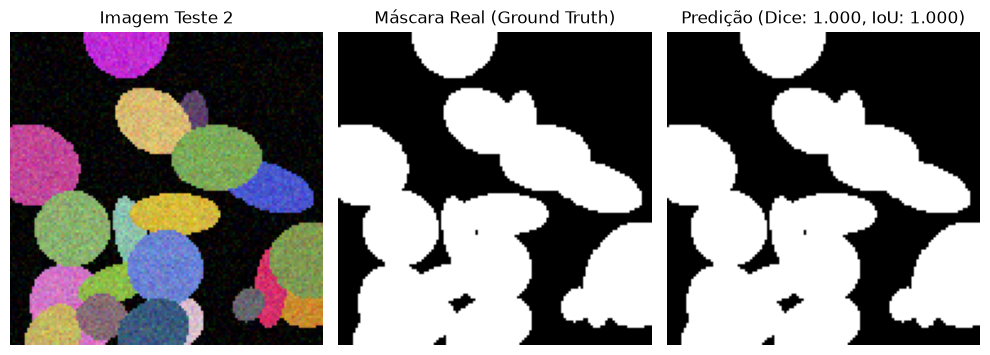

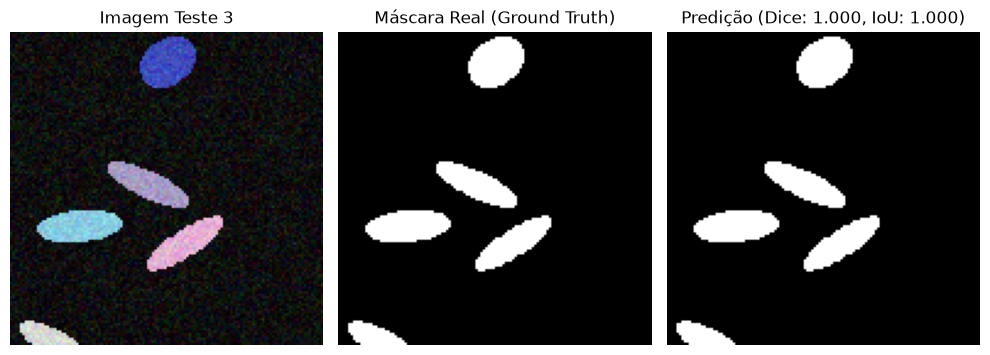

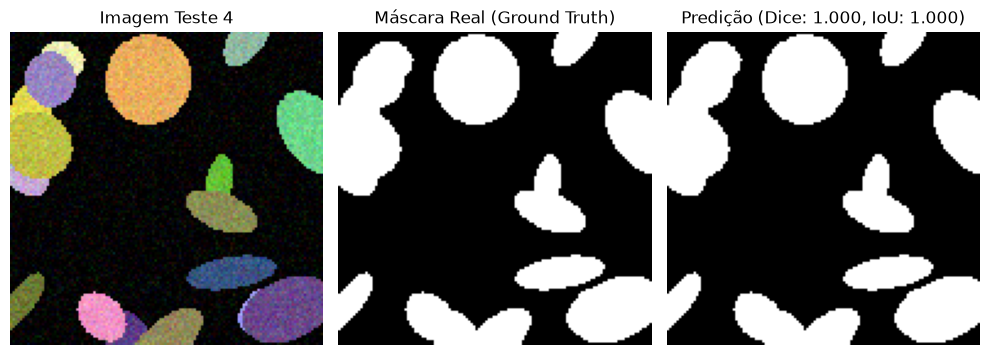

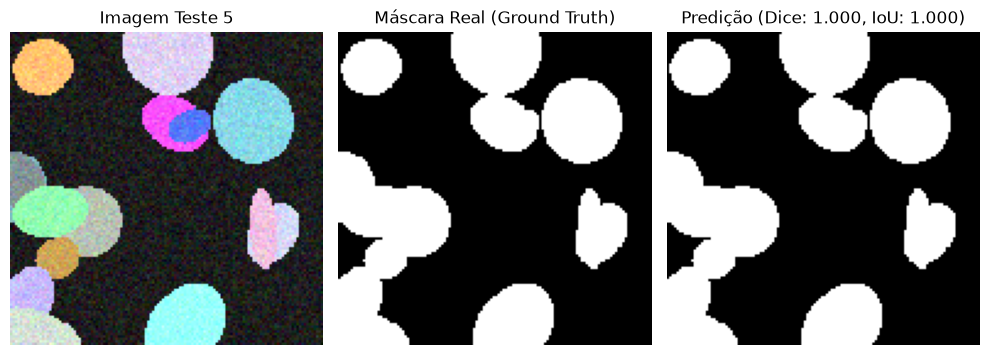

In [22]:
# Parte 0 — Visualização das Predições
utils.plot_predictions(model_synth, X_te_s, y_te_s, device=device, num_samples=5)

--- 
## Parte 1 — Baseline de Segmentação Semântica (DSB2018)

**Dados escolhidos:** Opção A

Microscopia com máscara individual por núcleo.

In [23]:
# Dados Reais — Carregamento DSB2018 (stage1_train)
stage1_path = "../data/stage1_train" if os.path.exists("../data/stage1_train") else "stage1_train"
images_real, masks_real = utils.carregar_dataset_real(stage1_path, target_size=(128, 128))
X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r = utils.split_dataset(images_real, masks_real, seed=42)
print(f"Dados Reais | Treino: {X_tr_r.shape[0]} | Val: {X_v_r.shape[0]} | Teste: {X_te_r.shape[0]}")

Split estratificado por modalidade (Total: 670):
  Treino (468): {np.str_('fluorescence'): 382, np.str_('brightfield_color'): 74, np.str_('brightfield_gray'): 12}
  Validação (101): {np.str_('fluorescence'): 82, np.str_('brightfield_color'): 16, np.str_('brightfield_gray'): 3}
  Teste (101): {np.str_('fluorescence'): 82, np.str_('brightfield_color'): 16, np.str_('brightfield_gray'): 3}
Dados Reais | Treino: 468 | Val: 101 | Teste: 101


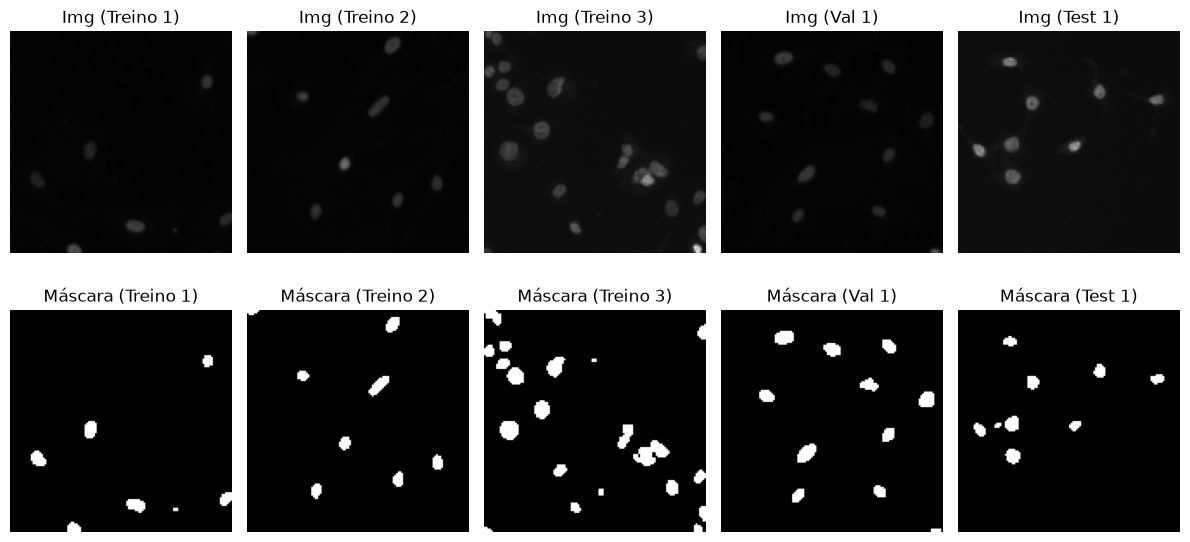

In [24]:
# Dados Reais — Visualização de Amostras
utils.plot_dataset_samples(X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r)

In [25]:
# Parte 1 (Item 1) — Treinamento e Avaliação Semântica (Dice & IoU)
model_real = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_real, X_tr_r, y_tr_r, X_v_r, y_v_r, device, num_epochs=10, batch_size=16)

dice_r, iou_r = utils.evaluate_model(model_real, X_te_r, y_te_r, device=device, batch_size=16)
print(f"\nMean Dice: {dice_r:.4f} | Mean IoU: {iou_r:.4f}")

Epoch [ 1/10] | Train Loss: 0.5676 | Val Loss: 0.4677
Epoch [ 2/10] | Train Loss: 0.3778 | Val Loss: 0.3003
Epoch [ 3/10] | Train Loss: 0.2971 | Val Loss: 0.2542
Epoch [ 4/10] | Train Loss: 0.2374 | Val Loss: 0.2246
Epoch [ 5/10] | Train Loss: 0.1918 | Val Loss: 0.1737
Epoch [ 6/10] | Train Loss: 0.1578 | Val Loss: 0.1452
Epoch [ 7/10] | Train Loss: 0.1334 | Val Loss: 0.1324
Epoch [ 8/10] | Train Loss: 0.1156 | Val Loss: 0.1090
Epoch [ 9/10] | Train Loss: 0.1014 | Val Loss: 0.1046
Epoch [10/10] | Train Loss: 0.0937 | Val Loss: 0.0958

Mean Dice: 0.8650 | Mean IoU: 0.7909


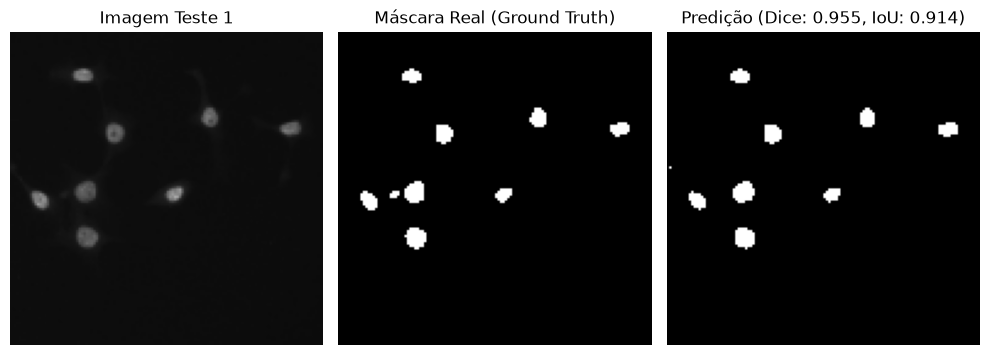

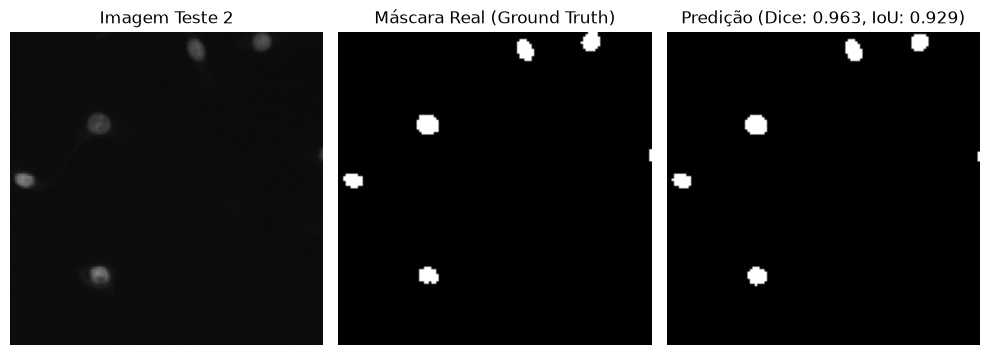

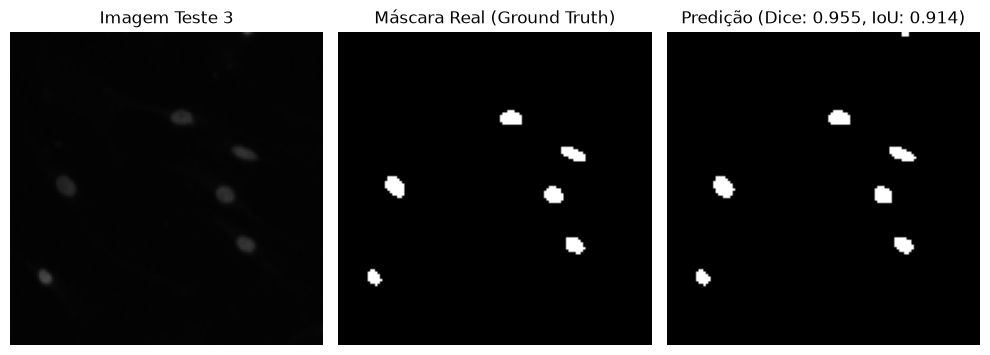

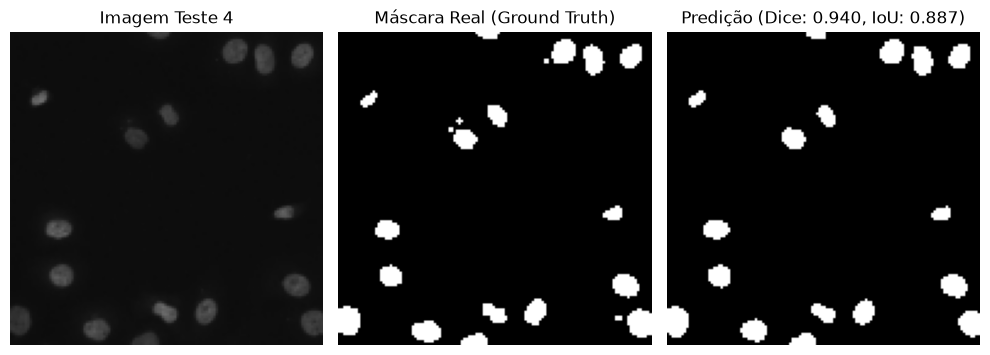

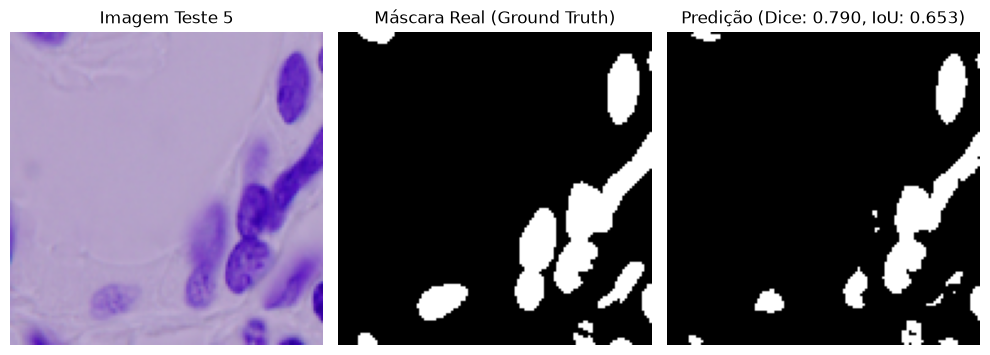

In [26]:
# Parte 1 (Item 1) — Visualização das Predições Binárias
utils.plot_predictions(model_real, X_te_r, y_te_r, device=device, num_samples=5)

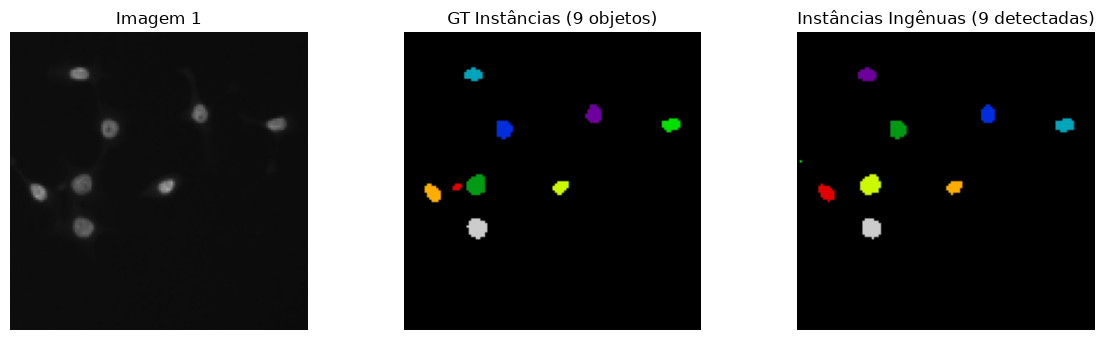

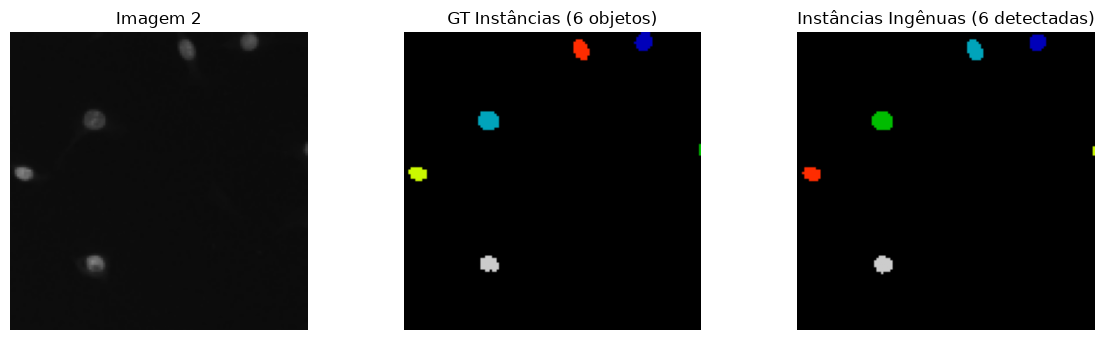

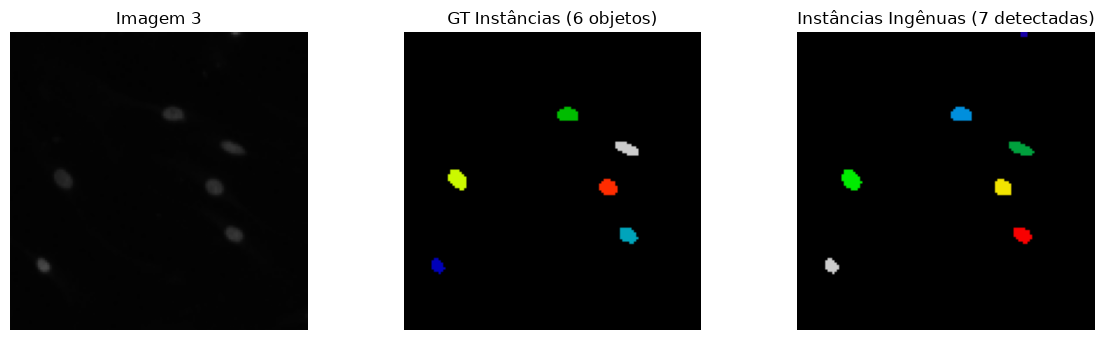

In [27]:
# Parte 1 (Item 2) — Extração Ingênua de Instâncias (Limiar + Componentes Conexos)
utils.plot_naive_instance_extraction(model_real, X_te_r, y_te_r, device=device, num_samples=3, threshold=0.5)


Avaliação por Instâncias (Reais (DSB2018))
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6512
  IoU = 0.55 : AP = 0.6107
  IoU = 0.60 : AP = 0.5885
  IoU = 0.65 : AP = 0.5665
  IoU = 0.70 : AP = 0.5393
  IoU = 0.75 : AP = 0.4962
  IoU = 0.80 : AP = 0.4511
  IoU = 0.85 : AP = 0.3599
  IoU = 0.90 : AP = 0.2196
  IoU = 0.95 : AP = 0.0606
\mAP@[.50:.95] Final: 0.4544
Erro Absoluto Médio de Contagem por Imagem: 11.62 objetos

--> Avaliando modelo Baseline no Teste Sintético (In-Domain)...

Avaliação por Instâncias (Sintéticos (Elipses - In-Domain))
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.4144
  IoU = 0.55 : AP = 0.3878
  IoU = 0.60 : AP = 0.3506
  IoU = 0.65 : AP = 0.3258
  IoU = 0.70 : AP = 0.3038
  IoU = 0.75 : AP = 0.2849
  IoU = 0.80 : AP = 0.2771
  IoU = 0.85 : AP = 0.2710
  IoU = 0.90 : AP = 0.2680
  IoU = 0.95 : AP = 0.2628
\mAP@[.50:.95] Final: 0.3146
Erro Absoluto Médio de Contagem 

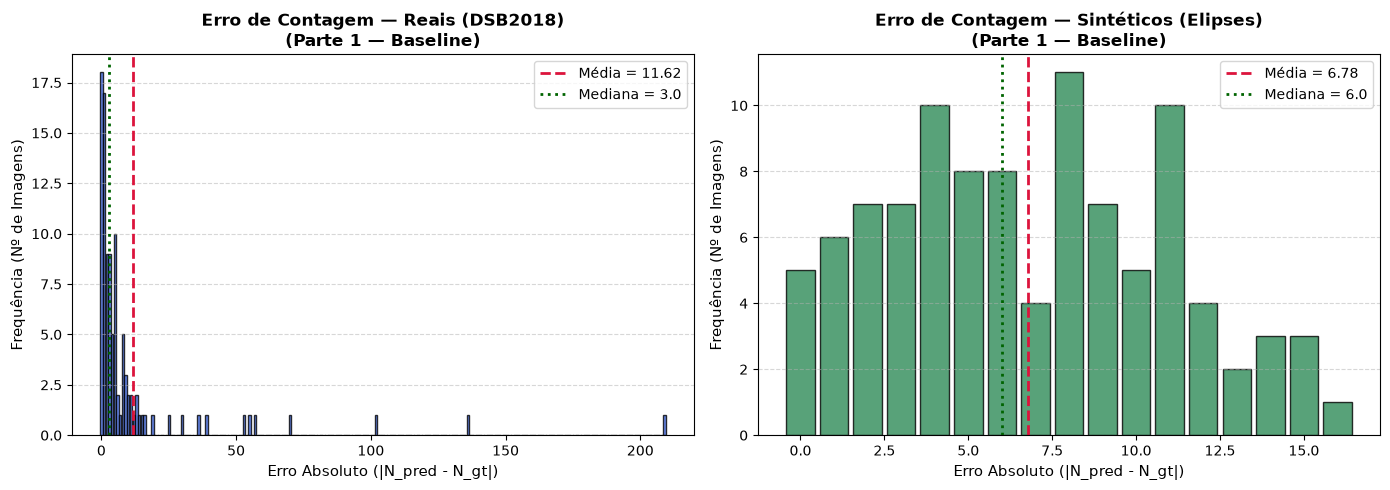

In [28]:
# Parte 1 (Item 3) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95, passo 0,05), mAP@[.50:.95] e Erro Absoluto de Contagem por Imagem
res_instance_real = utils.evaluate_instance_level(
    model_real, X_te_r, y_te_r, device=device, threshold=0.5, matching_method="hungarian", dataset_name="Reais (DSB2018)"
)

# Treinar e avaliar modelo baseline nos dados sintéticos (In-Domain)
model_synth, res_instance_synth = utils.treinar_e_avaliar_sintetico_baseline(
    X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s, device=device, model=model_synth
)

# Comparação e Histogramas Reais vs. Sintéticos (Parte 1)
utils.avaliar_e_plotar_comparativo_instancias(
    res_real=res_instance_real,
    res_synth=res_instance_synth,
    titulo_metodo="Parte 1 — Baseline"
)


### Parte 1 (Item 4) — Métricas de Avaliação

### Regra de Matching: Algoritmo Húngaro

- **Como funciona:**  
  1. Constrói-se a matriz de custo $C_{i,j} = 1.0 - \text{IoU}(GT_i, Pred_j)$ entre todas as instâncias reais e preditas.  
  2. O algoritmo de Kuhn-Munkres (`linear_sum_assignment`) resolve o casamento bipartido que **minimiza o custo global** (ou seja, maximiza a soma total de IoU).  
  3. O par casado $(i, j)$ é computado como **Verdadeiro Positivo (TP)** se $\text{IoU}_{i,j} \ge t$ (para cada limiar $t \in [0.50, 0.95]$); caso contrário, gera FP e FN.

- **Por que escolhemos:**  
  - **Ótimo Global:** Elimina o problema da regra gulosa (*Greedy*), evitando que uma escolha local de maior IoU impeça outros casamentos válidos.  

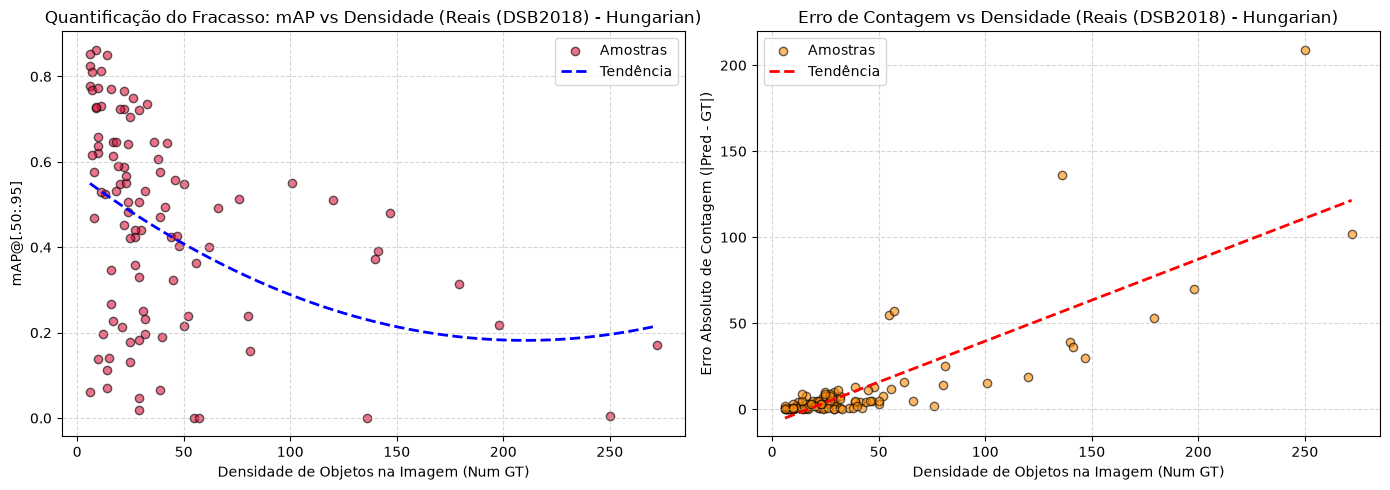

In [29]:
# Parte 1 (Item 5) — Quantificação do Fracasso: Gráficos de mAP e Erro de Contagem vs. Densidade de Objetos
utils.plot_quantify_failure(res_instance_real, dataset_name="Reais (DSB2018)")

---
## Parte 2 — Uma cabeça de instâncias

**Trilha escolhida:** Trilha A

Fronteiras e watershed.

In [30]:
# Parte 2 (Trilha A) — Geração dos Alvos de 3 Classes (Fundo=0, Interior=1, Fronteira=2)
y_tr_3c = utils.gerar_alvos_trilha_a(y_tr_r, border_thickness=1)
y_v_3c = utils.gerar_alvos_trilha_a(y_v_r, border_thickness=1)
y_te_3c = utils.gerar_alvos_trilha_a(y_te_r, border_thickness=1)

class_weights = utils.calcular_pesos_classes_trilha_a(y_tr_3c)
print(f"Shape treino: {y_tr_3c.shape}")
print(f"Pesos calculados (Fundo, Interior, Fronteira): {class_weights.numpy()}")

Shape treino: (468, 128, 128)
Pesos calculados (Fundo, Interior, Fronteira): [0.3673659 1.111394  1.5212401]


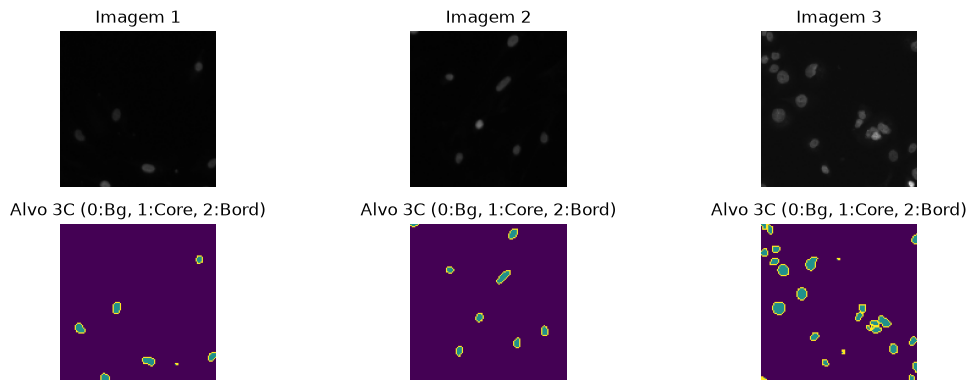

In [31]:
# Parte 2 (Trilha A) — Visualização dos Alvos de 3 Classes
utils.plot_trilha_a_samples(X_tr_r, y_tr_3c, num_samples=3)

In [32]:
# Parte 2 (Trilha A) — Treinamento ResUNet com Cross-Entropy Balanceada
head_trilha_a = utils.create_segmentation_head(in_channels=32, out_channels=3, head_type="conv1x1")
model_trilha_a = utils.UNetResNet(head=head_trilha_a, pretrained=True, freeze_backbone=True)
utils.train_model_trilha_a_twophase(
    model_trilha_a, X_tr_r, y_tr_3c, X_v_r, y_v_3c, device,
    class_weights=class_weights, gamma=0.0,
    epochs_phase1=10, epochs_phase2=10,
    batch_size=16, lr_phase1=0.001, lr_phase2=0.0001
)


[Fase 1] Backbone CONGELADO | 10 épocas | LR=0.001
  Epoch [ 1/10] | Train: 0.3643 | Val: 0.3503
  Epoch [ 2/10] | Train: 0.2275 | Val: 0.1924
  Epoch [ 3/10] | Train: 0.1769 | Val: 0.1604
  Epoch [ 4/10] | Train: 0.1518 | Val: 0.1311
  Epoch [ 5/10] | Train: 0.1356 | Val: 0.1262
  Epoch [ 6/10] | Train: 0.1249 | Val: 0.1239
  Epoch [ 7/10] | Train: 0.1184 | Val: 0.1207
  Epoch [ 8/10] | Train: 0.1127 | Val: 0.1124
  Epoch [ 9/10] | Train: 0.1081 | Val: 0.1109
  Epoch [10/10] | Train: 0.1045 | Val: 0.1071

[Fase 2] Backbone DESCONGELADO (fine-tuning) | 10 épocas | LR=0.0001
  Epoch [ 1/10] | Train: 0.0988 | Val: 0.0994
  Epoch [ 2/10] | Train: 0.0971 | Val: 0.0968
  Epoch [ 3/10] | Train: 0.0925 | Val: 0.0972
  Epoch [ 4/10] | Train: 0.0900 | Val: 0.0975
  Epoch [ 5/10] | Train: 0.0884 | Val: 0.0961
  Epoch [ 6/10] | Train: 0.0869 | Val: 0.0965
  Epoch [ 7/10] | Train: 0.0857 | Val: 0.0967
  Epoch [ 8/10] | Train: 0.0843 | Val: 0.0970
  Epoch [ 9/10] | Train: 0.0844 | Val: 0.0972
  Ep

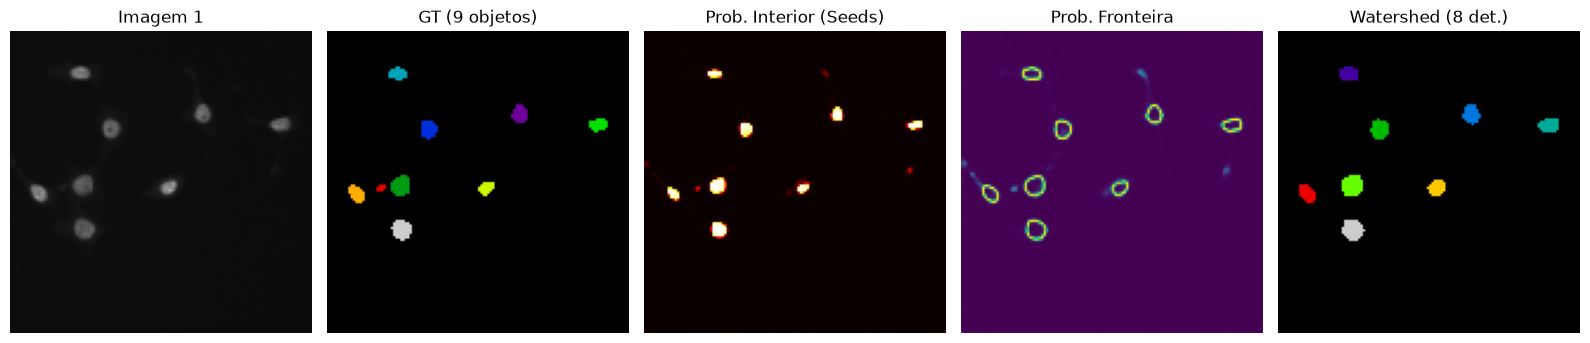

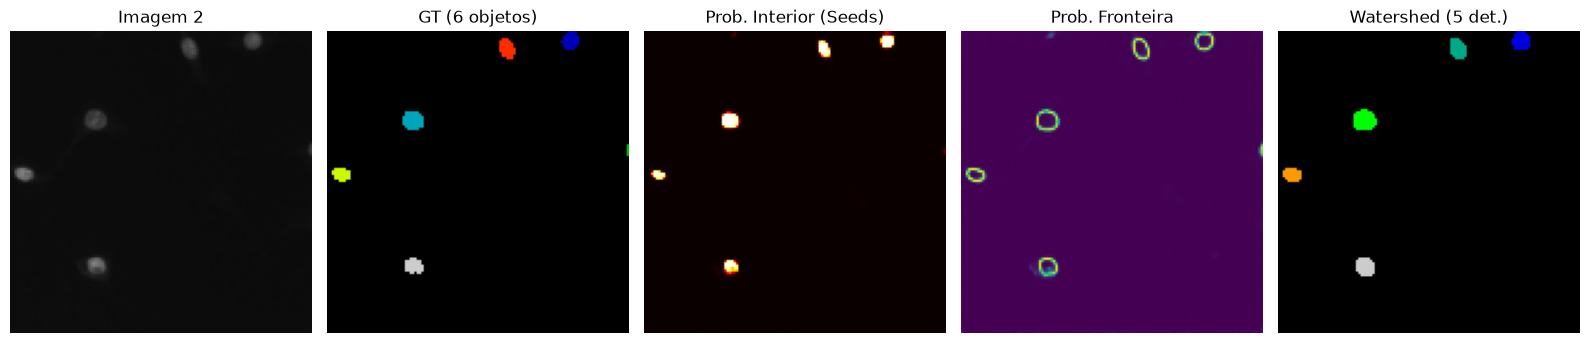

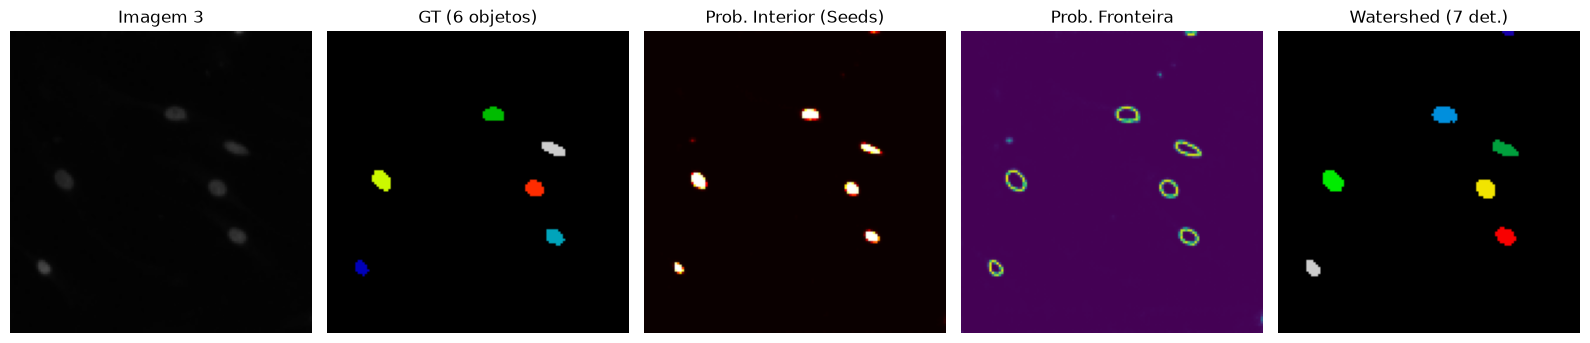

In [33]:
# Parte 2 (Trilha A) — Visualização das Predições Intermediárias e Decodificação Watershed
utils.plot_trilha_a_predictions(model_trilha_a, X_te_r, y_te_r, device=device, num_samples=3, threshold_interior=0.35, threshold_fg=0.35)


Avaliação por Instâncias (Reais (DSB2018))
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.7181
  IoU = 0.55 : AP = 0.6928
  IoU = 0.60 : AP = 0.6701
  IoU = 0.65 : AP = 0.6344
  IoU = 0.70 : AP = 0.5868
  IoU = 0.75 : AP = 0.5152
  IoU = 0.80 : AP = 0.4246
  IoU = 0.85 : AP = 0.2685
  IoU = 0.90 : AP = 0.1129
  IoU = 0.95 : AP = 0.0154

mAP@[.50:.95] Trilha A: 0.4639
Erro Absoluto Médio de Contagem por Imagem: 9.41 objetos

--> Gerando alvos de 3 classes para as Elipses Sintéticas...
--> Treinando U-Net Trilha A nos dados Sintéticos (10 épocas)...
Epoch [ 1/10] | Train Loss: 0.1824 | Val Loss: 0.1596
Epoch [ 2/10] | Train Loss: 0.0768 | Val Loss: 0.0573
Epoch [ 3/10] | Train Loss: 0.0458 | Val Loss: 0.0354
Epoch [ 4/10] | Train Loss: 0.0310 | Val Loss: 0.0249
Epoch [ 5/10] | Train Loss: 0.0225 | Val Loss: 0.0196
Epoch [ 6/10] | Train Loss: 0.0169 | Val Loss: 0.0170
Epoch [ 7/10] | Train Loss: 0.0132 | Val Loss: 0.0148
Epoch [ 8/10] | Train

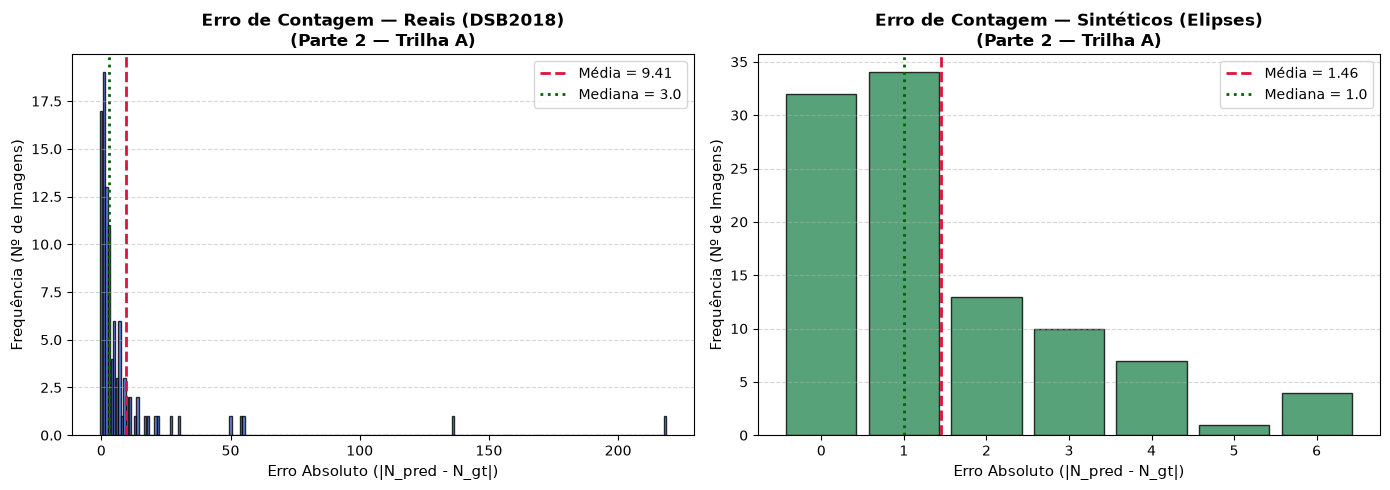

In [34]:
# Parte 2 (Trilha A) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95), mAP@[.50:.95] e Erro de Contagem
res_trilha_a = utils.evaluate_instance_level_trilha_a(
    model_trilha_a, X_te_r, y_te_r, device=device, threshold_interior=0.35, threshold_fg=0.35, matching_method="hungarian", dataset_name="Reais (DSB2018)"
)

# Treinar e avaliar modelo Trilha A nos dados sintéticos (In-Domain)
model_synth_trilha_a, res_trilha_a_synth = utils.treinar_e_avaliar_sintetico_trilha_a(
    X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s, device=device, num_epochs=10, batch_size=16
)

# Comparação e Histogramas Reais vs. Sintéticos (Parte 2)
utils.avaliar_e_plotar_comparativo_instancias(
    res_real=res_trilha_a,
    res_synth=res_trilha_a_synth,
    titulo_metodo="Parte 2 — Trilha A"
)



   COMPARAÇÃO: BASELINE (Parte 1) vs TRILHA A (Parte 2)   
                   Dataset: Reais (DSB2018)                
Métrica                             | Baseline (Ingênua)   | Trilha A (Watershed)
--------------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.4544               | 0.4639              
Erro Médio de Contagem (abs)        | 11.62                | 9.41                
AP @ IoU=0.50                       | 0.6512               | 0.7181              
AP @ IoU=0.75                       | 0.4962               | 0.5152              


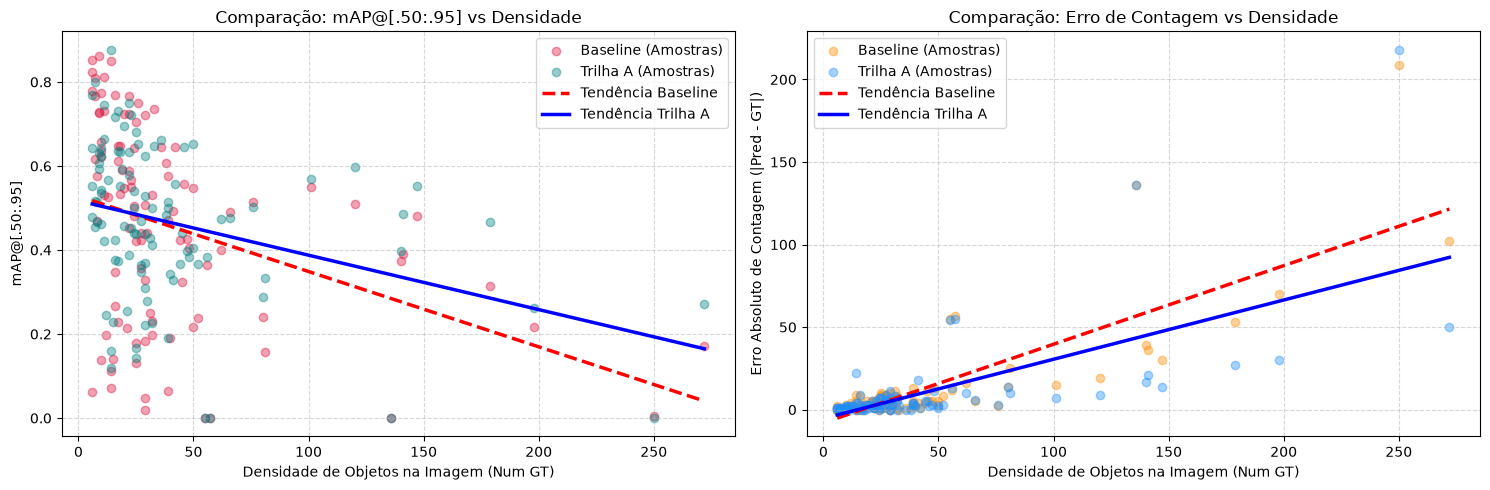


   COMPARAÇÃO: BASELINE (Parte 1) vs TRILHA A (Parte 2)   
                   Dataset: Sintéticos (Elipses)                
Métrica                             | Baseline (Ingênua)   | Trilha A (Watershed)
--------------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.3146               | 0.7055              
Erro Médio de Contagem (abs)        | 6.78                 | 1.46                
AP @ IoU=0.50                       | 0.4144               | 0.7935              
AP @ IoU=0.75                       | 0.2849               | 0.6915              


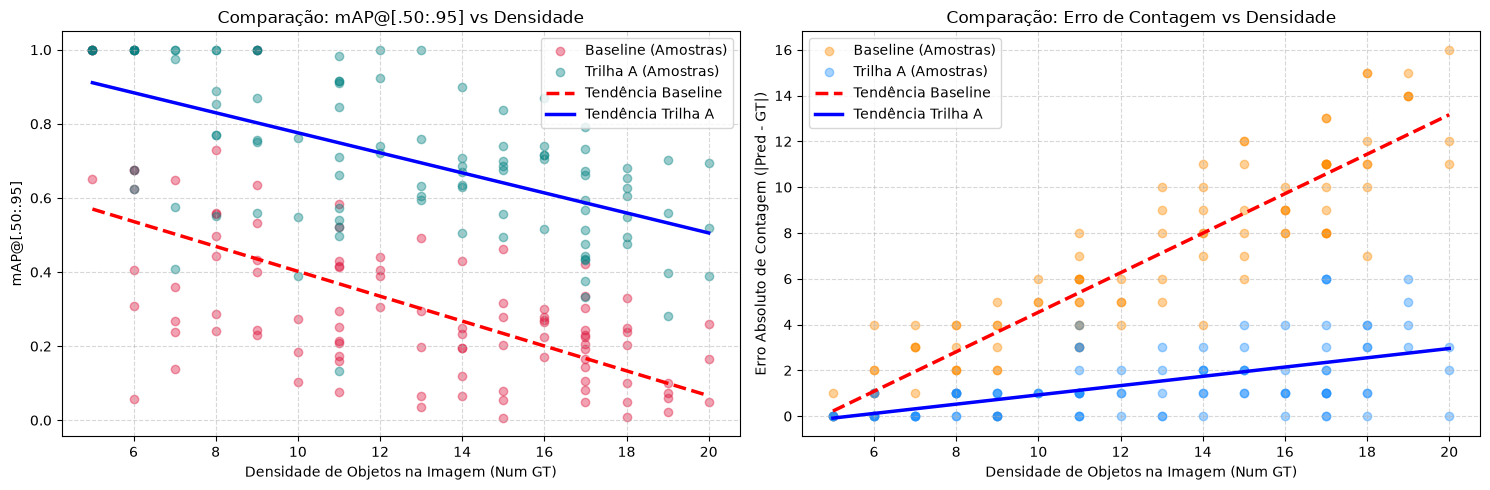

In [35]:
# Parte 2 (Trilha A) — Comparação Lado a Lado: Baseline (Parte 1) vs. Trilha A (Parte 2)
# Comparação nos dados Reais
utils.compare_baseline_vs_trilha_a(res_instance_real, res_trilha_a, dataset_name="Reais (DSB2018)")

# Comparação nos dados Sintéticos
utils.compare_baseline_vs_trilha_a(res_instance_synth, res_trilha_a_synth, dataset_name="Sintéticos (Elipses)")


---
## Parte 3 — Ablações


**Eixos Escolhidos:**

Eixo 1: Recuperação de Resolução \
Eixo 2: Função de Perda

In [36]:
# Parte 3 (Eixo 1) — Ablação de Recuperação de Resolução: Skip Connections (U-Net) vs. Pool Indices (SegNet)
seeds_ablação = [42, 123]
resultados_eixo1 = {}

# 1. Mecanismo A: Skip Connections (U-Net / ResUNet, slides 25–29)
print("Executando Eixo 1: Skip Connections (U-Net) com 2 seeds...")
resultados_eixo1["Skip Connections (U-Net)"] = utils.rodar_ablação_seeds(
    utils.criar_unet_res18, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
    device, seeds=seeds_ablação, class_weights=class_weights, gamma=0.0,
    num_epochs=12, batch_size=16, learning_rate=0.0005
)

# 2. Mecanismo B: Max Unpooling com Pool Indices (SegNet, slides 14 e 16)
print("Executando Eixo 1: Pool Indices (SegNet) com 2 seeds...")
resultados_eixo1["Pool Indices (SegNet)"] = utils.rodar_ablação_seeds(
    utils.criar_segnet, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
    device, seeds=seeds_ablação, class_weights=class_weights, gamma=0.0,
    num_epochs=12, batch_size=16, learning_rate=0.001
)

# Exibir tabela consolidada com Média ± Desvio Padrão
utils.imprimir_tabela_ablação(resultados_eixo1, titulo="Eixo 1: Mecanismos de Recuperação de Resolução")


Executando Eixo 1: Skip Connections (U-Net) com 2 seeds...
Epoch [ 1/12] | Train Loss: 0.3653 | Val Loss: 0.3457
Epoch [ 2/12] | Train Loss: 0.2728 | Val Loss: 0.2384
Epoch [ 3/12] | Train Loss: 0.2305 | Val Loss: 0.2043
Epoch [ 4/12] | Train Loss: 0.1984 | Val Loss: 0.1837
Epoch [ 5/12] | Train Loss: 0.1757 | Val Loss: 0.1575
Epoch [ 6/12] | Train Loss: 0.1570 | Val Loss: 0.1526
Epoch [ 7/12] | Train Loss: 0.1436 | Val Loss: 0.1379
Epoch [ 8/12] | Train Loss: 0.1358 | Val Loss: 0.1320
Epoch [ 9/12] | Train Loss: 0.1279 | Val Loss: 0.1266
Epoch [10/12] | Train Loss: 0.1205 | Val Loss: 0.1176
Epoch [11/12] | Train Loss: 0.1138 | Val Loss: 0.1189
Epoch [12/12] | Train Loss: 0.1115 | Val Loss: 0.1111
Epoch [ 1/12] | Train Loss: 0.4042 | Val Loss: 0.4327
Epoch [ 2/12] | Train Loss: 0.2906 | Val Loss: 0.2573
Epoch [ 3/12] | Train Loss: 0.2464 | Val Loss: 0.2178
Epoch [ 4/12] | Train Loss: 0.2130 | Val Loss: 0.1912
Epoch [ 5/12] | Train Loss: 0.1866 | Val Loss: 0.1658
Epoch [ 6/12] | Train L

In [37]:
# Parte 3 (Eixo 2) — Ablação da Função de Perda: CE vs. CE Balanceada (α) vs. Focal (γ) vs. Focal Balanceada (α, γ)
seeds_ablação = [42, 123]
resultados_eixo2 = {}

configuracoes_perda = [
    ("CE Padrão (γ=0, sem α)", None, 0.0),
    ("CE Balanceada (γ=0, com α)", class_weights, 0.0),
    ("Focal Pura (γ=2, sem α)", None, 2.0),
    ("Focal Balanceada (γ=1, com α)", class_weights, 1.0),
    ("Focal Balanceada (γ=2, com α)", class_weights, 2.0),
    ("Focal Balanceada (γ=5, com α)", class_weights, 5.0),
]

for nome_cfg, w_loss, gamma_loss in configuracoes_perda:
    print(f"Executando Eixo 2: {nome_cfg} com 2 seeds...")
    resultados_eixo2[nome_cfg] = utils.rodar_ablação_seeds(
        utils.criar_unet_res18, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
        device, seeds=seeds_ablação, class_weights=w_loss, gamma=gamma_loss,
        num_epochs=12, batch_size=16, learning_rate=0.0005
    )

# Exibir tabela consolidada com Média ± Desvio Padrão
utils.imprimir_tabela_ablação(resultados_eixo2, titulo="Eixo 2: Função de Perda e Desbalanceamento")


Executando Eixo 2: CE Padrão (γ=0, sem α) com 2 seeds...
Epoch [ 1/12] | Train Loss: 0.6989 | Val Loss: 0.6269
Epoch [ 2/12] | Train Loss: 0.5062 | Val Loss: 0.4242
Epoch [ 3/12] | Train Loss: 0.3826 | Val Loss: 0.3210
Epoch [ 4/12] | Train Loss: 0.3008 | Val Loss: 0.2652
Epoch [ 5/12] | Train Loss: 0.2481 | Val Loss: 0.2219
Epoch [ 6/12] | Train Loss: 0.2110 | Val Loss: 0.2042
Epoch [ 7/12] | Train Loss: 0.1886 | Val Loss: 0.1974
Epoch [ 8/12] | Train Loss: 0.1739 | Val Loss: 0.1732
Epoch [ 9/12] | Train Loss: 0.1583 | Val Loss: 0.1586
Epoch [10/12] | Train Loss: 0.1463 | Val Loss: 0.1556


KeyboardInterrupt: 

---
## Parte 4 — Inferência em mosaico

In [38]:
# Parte 4 (Item 1) — Montagem de Imagem Grande em Mosaico (2x2 da Mesma Modalidade no Teste Real)
modalidades_teste = utils.identificar_modalidades(X_te_r)
indices_mosaico = np.where(modalidades_teste == 'fluorescence')[0][:4]

amostras_img = X_te_r[indices_mosaico]
amostras_mask = y_te_r[indices_mosaico]

mosaic_img, mosaic_gt = utils.criar_mosaico_imagens(amostras_img, amostras_mask, grid_shape=(2, 2))
num_gt_mosaico = len(np.unique(mosaic_gt[mosaic_gt > 0]))

print(f"Modalidade das imagens do mosaico: 'fluorescence'")
print(f"Dimensões da imagem grande: {mosaic_img.shape[:2]} | Canais: {mosaic_img.shape[2]}")
print(f"Total de núcleos reais no Ground Truth (reindexados de 1 a N): {num_gt_mosaico} objetos")


Modalidade das imagens do mosaico: 'fluorescence'
Dimensões da imagem grande: (256, 256) | Canais: 3
Total de núcleos reais no Ground Truth (reindexados de 1 a N): 45 objetos


In [39]:
# Parte 4 (Item 2) — Inferência em Tiles com Sobreposição (Slide 83 da aula)

pred_sem_fusao, semantic_prob_mosaic, tiles_data = utils.inferencia_mosaico_tiles(
    model=model_trilha_a,
    mosaic_img=mosaic_img,
    tile_size=128,
    stride=96,
    device=device,
    threshold_interior=0.35,
    threshold_fg=0.35,
    min_marker_size=1
)

num_pred_sem = len(np.unique(pred_sem_fusao[pred_sem_fusao > 0]))
print(f"Instâncias detectadas antes da correção: {num_pred_sem} (Ground Truth: {num_gt_mosaico})")

Instâncias detectadas antes da correção: 50 (Ground Truth: 45)


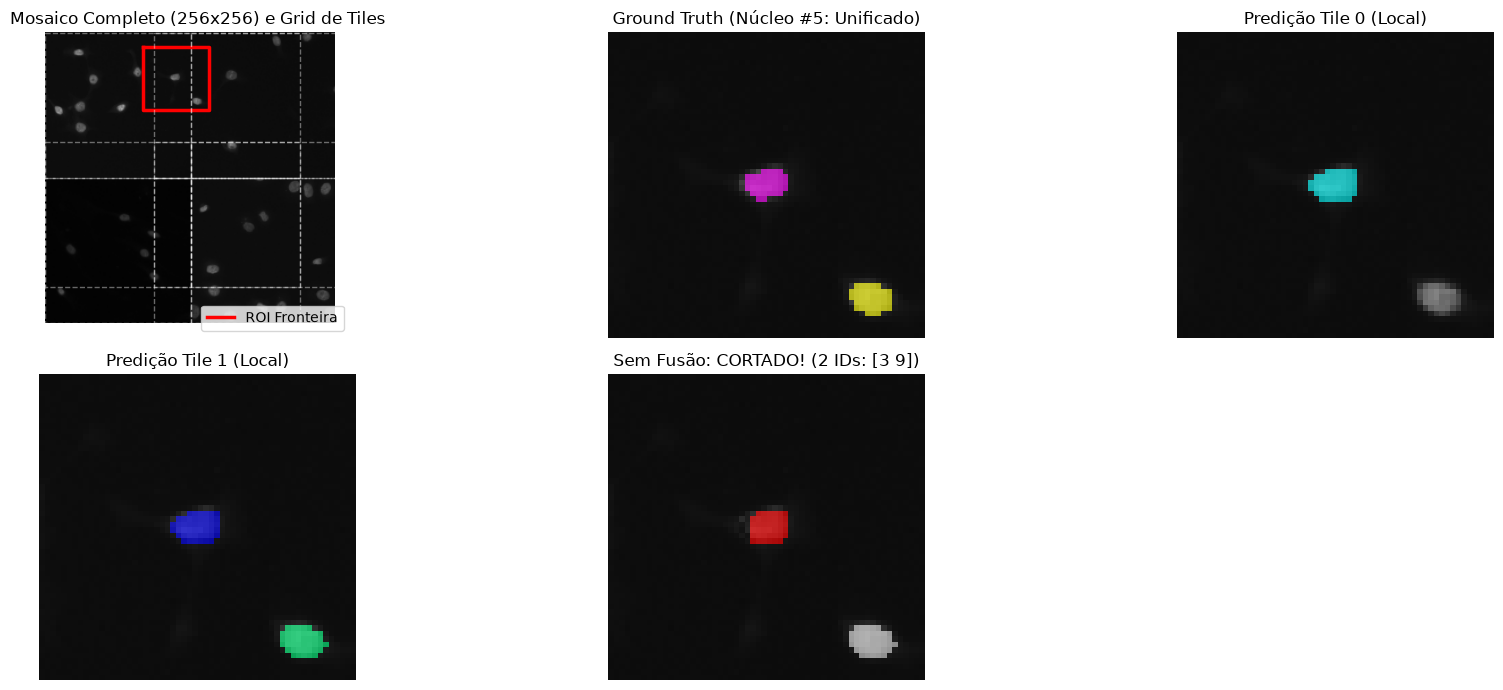

In [40]:
# Parte 4 (Item 3) — Fratura de Instâncias na Fronteira entre Tiles
utils.plot_objeto_fronteira_tiles(
    mosaic_img=mosaic_img,
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_sem_fusao, # Ainda não corrigido
    tiles_data=tiles_data,
    tile_size=128,
    margin=25,
    corrigido=False
)

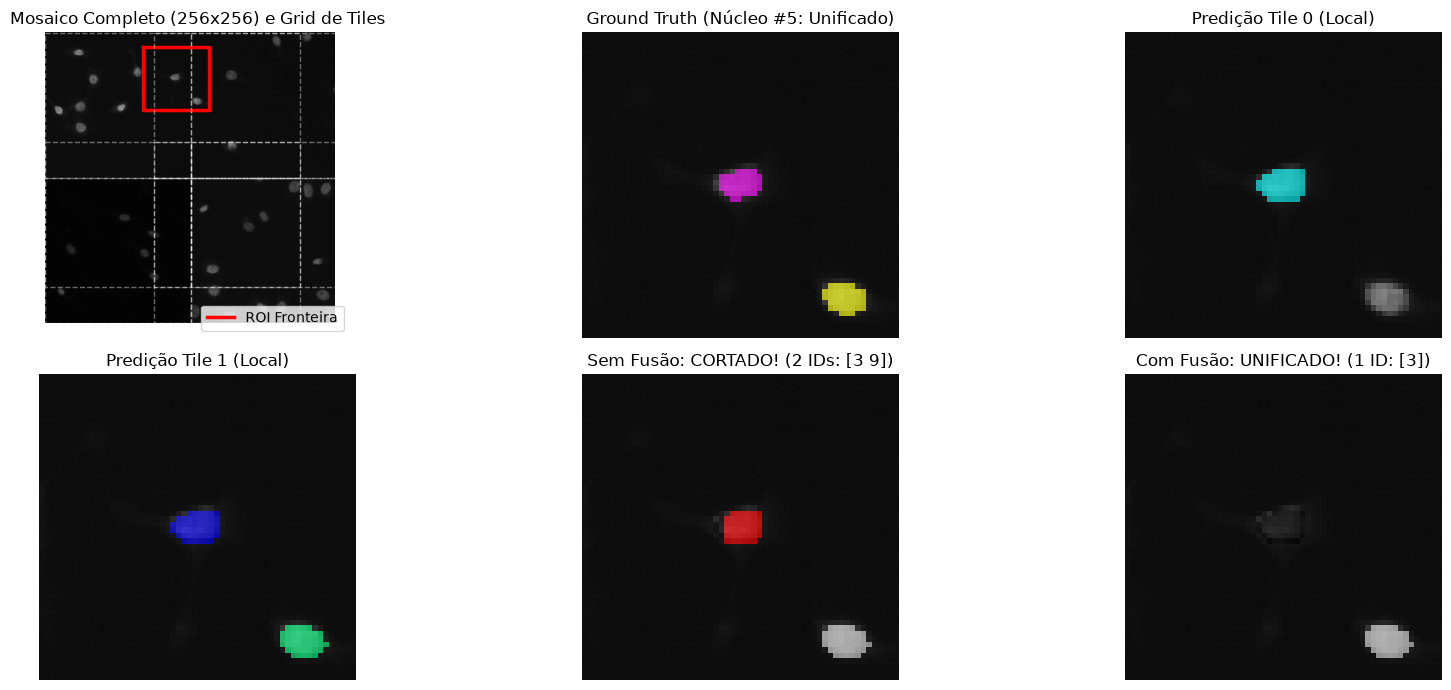


      COMPARAÇÃO NO MOSAICO: ANTES VS DEPOIS DA FUSÃO DE INSTÂNCIAS     
Métrica                             | Antes da Fusão   | Depois da Fusão  | Variação  
---------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.3975           | 0.3978           |    +0.0003
AP @ IoU=0.50                       | 0.6102           | 0.6034           |    -0.0067
AP @ IoU=0.75                       | 0.4615           | 0.4762           |    +0.0147
Número de Instâncias Preditas       | 50               | 48               |         -2
Instâncias no Ground Truth          | 45               | 45               | --        
Erro Absoluto de Contagem           | 5                | 3                |         -2


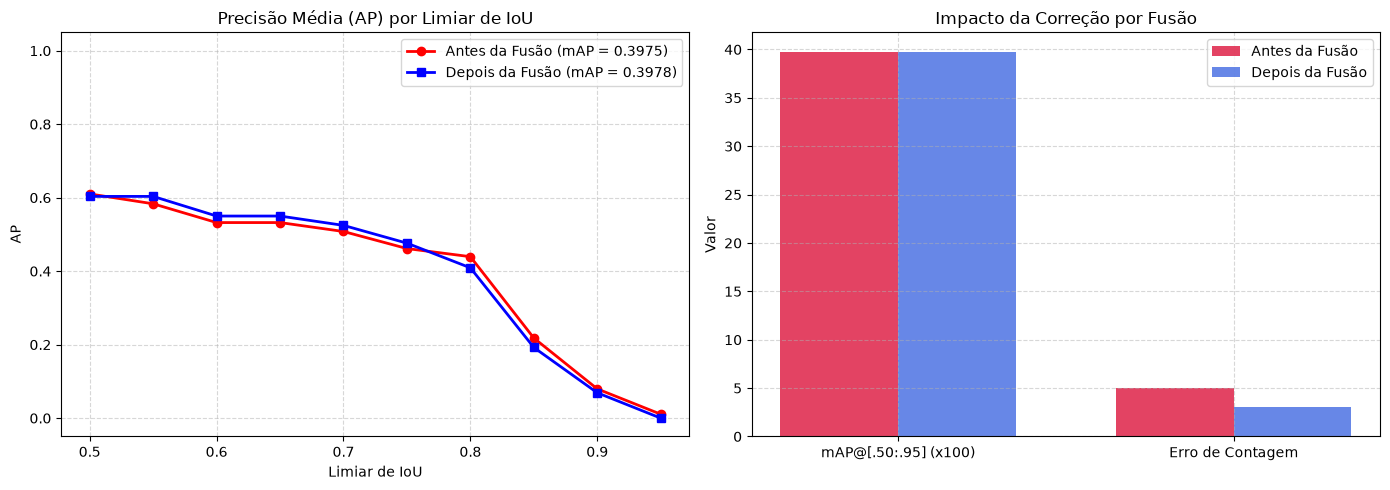

In [41]:
# Parte 4 (Item 4) — Correção via Fusão de Instâncias por IoU na Faixa de Sobreposição (Union-Find)
pred_com_fusao = utils.fundir_instancias_tiles(
    tiles_data=tiles_data,
    image_shape=mosaic_img.shape,
    tile_size=128,
    min_overlap_iou=0.20,
    min_relative_inter=0.30
)

utils.plot_objeto_fronteira_tiles(
    mosaic_img=mosaic_img,
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_com_fusao,
    tiles_data=tiles_data,
    tile_size=128,
    margin=25
)

res_mosaico = utils.avaliar_e_comparar_mosaico(
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_com_fusao,
    matching_method="hungarian"
)

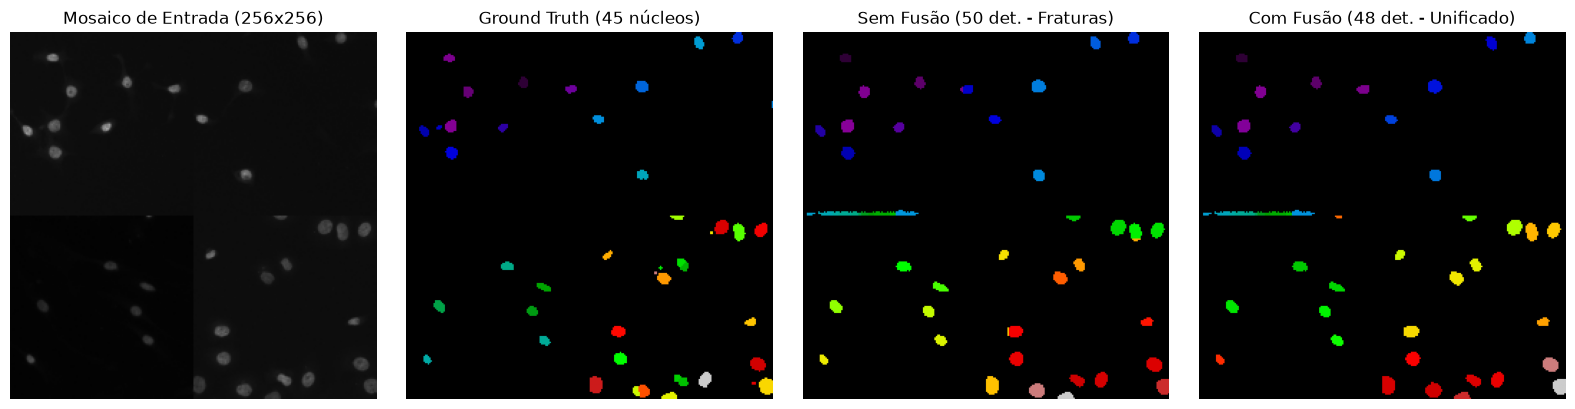

In [42]:
# Parte 4 — Visualização Geral do Mosaico Completo
utils.plot_mosaico_completo(mosaic_img, mosaic_gt, pred_sem_fusao, pred_com_fusao)

---
## Parte 5 — Galeria de falhas

   CAMPO RECEPTIVO TEÓRICO: ENCODER RESNET18 (SLIDES 35-38)
Camada                              | Kernel   | Stride   | Jump     | RF (px)   
--------------------------------------------------------------------------------
Input                               | 1        | 1        | 1        | 1         
conv1 (7x7)                         | 7        | 2        | 2        | 7         
maxpool (3x3)                       | 3        | 2        | 4        | 11        
layer1.b0.c1 (3x3)                  | 3        | 1        | 4        | 19        
layer1.b0.c2 (3x3)                  | 3        | 1        | 4        | 27        
layer1.b1.c1 (3x3)                  | 3        | 1        | 4        | 35        
layer1.b1.c2 (3x3) [Skip L1]        | 3        | 1        | 4        | 43        
layer2.b0.c1 (3x3, s2)              | 3        | 2        | 8        | 51        
layer2.b0.c2 (3x3)                  | 3        | 1        | 8        | 67        
layer2.b1.c1 (3x3)                  | 3

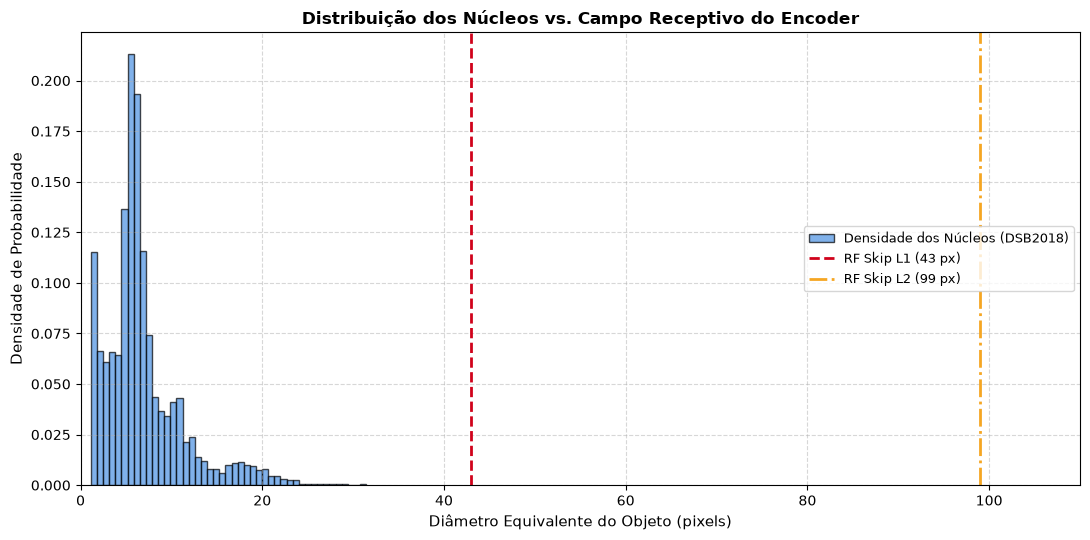

   COBERTURA TEÓRICA DO CAMPO RECEPTIVO SOBRE OS NÚCLEOS DO DSB2018
Total de núcleos analisados: 4158
Diâmetro Médio: 6.82 px | Mediana: 5.86 px | Máximo: 31.43 px
Núcleos com diâmetro <= RF Skip L1 (43 px) :  4158 / 4158 (100.00%)
Núcleos com diâmetro <= RF Skip L2 (99 px) :  4158 / 4158 (100.00%)
Diagnóstico Teórico: Objetos gigantes (> 30 px) aproximam-se do limiar de visão da Skip L1,
exigindo que o modelo recorra aos níveis mais profundos (L2/L3) para contextualização global.


In [43]:
# Parte 5 (Item Obrigatório) — Cálculo do Campo Receptivo Teórico
# Fórmulas de recorrência da aula (slides 35-42):
#   j_out = j_in * s
#   r_out = r_in + (k_eff - 1) * j_in
#   k_eff = k + (k - 1) * (d - 1)

tabela_rf = utils.calcular_campo_receptivo_resnet18()
utils.imprimir_tabela_campo_receptivo(tabela_rf)

# Extração da distribuição de diâmetros equivalentes dos núcleos reais
diametros_gt, areas_gt = utils.extrair_diametros_objetos(y_te_r)

# Distribuição dos Núcleos vs. Skips do Encoder & Padrão vs. Atrous
utils.plot_campo_receptivo_vs_dataset(diametros_gt, tabela_rf)


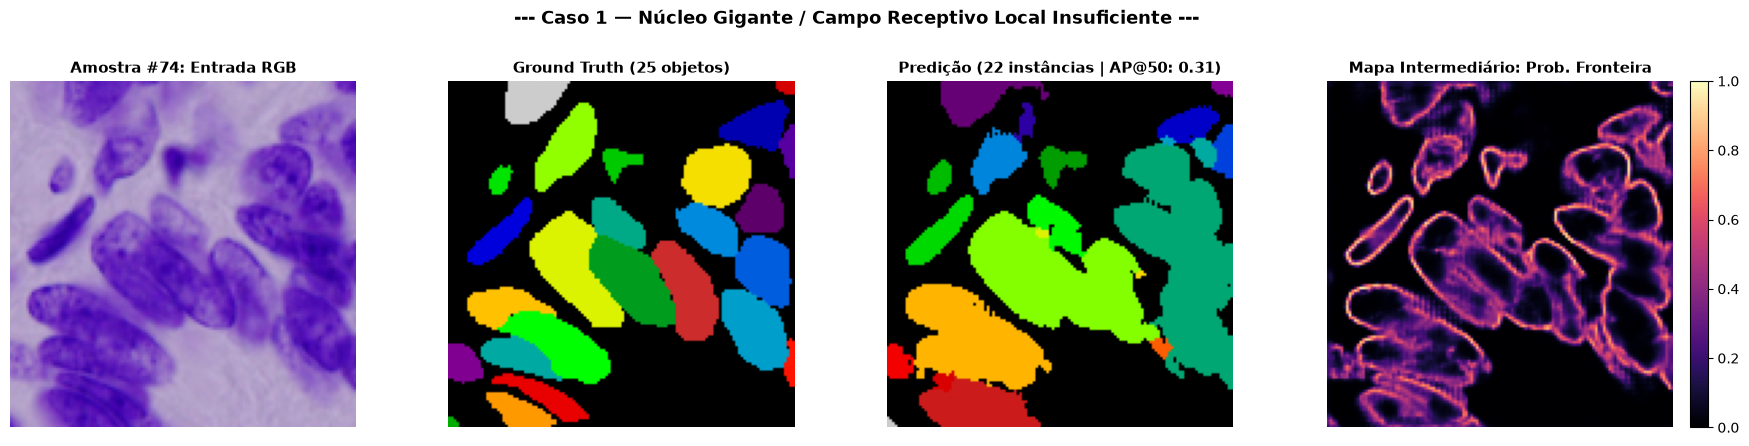

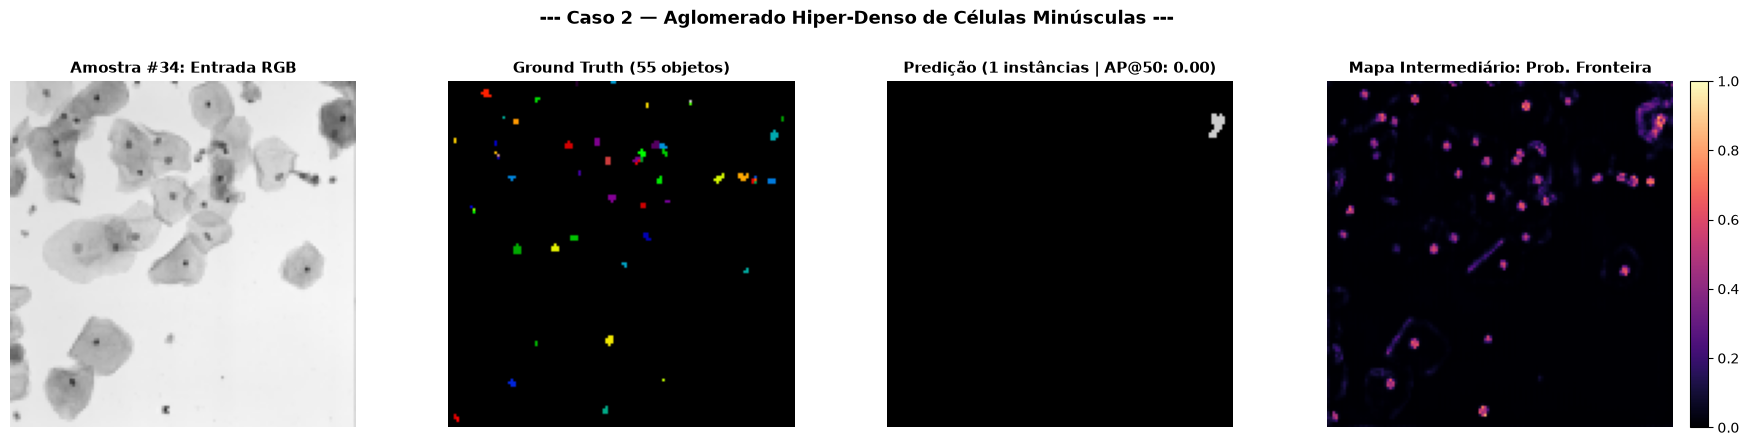

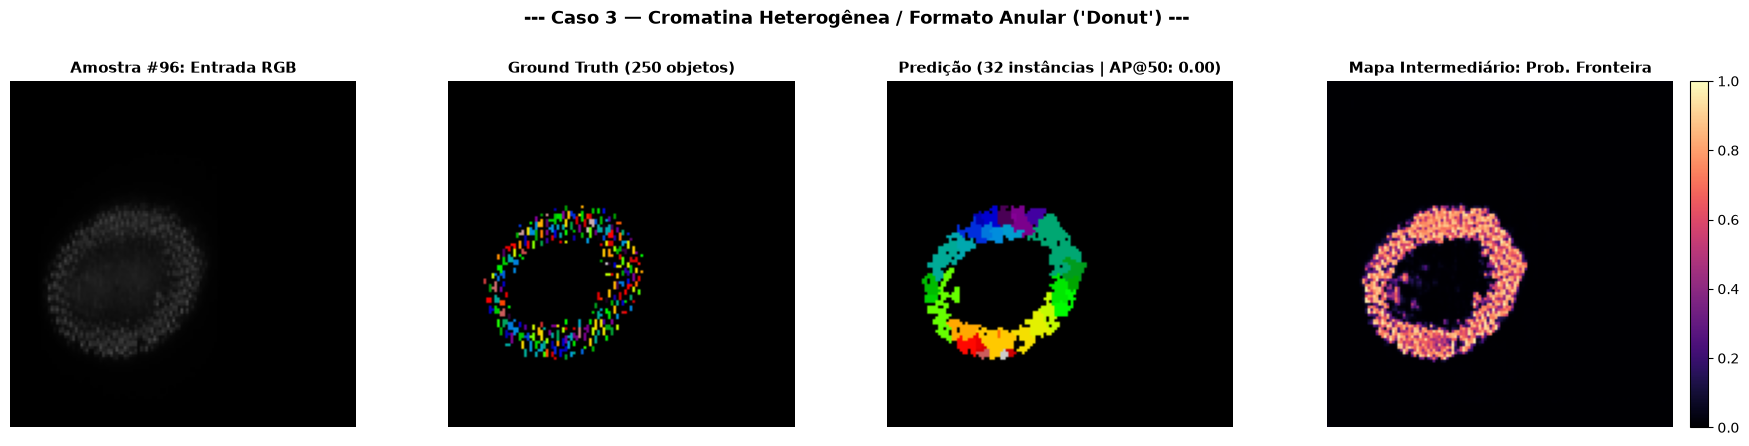

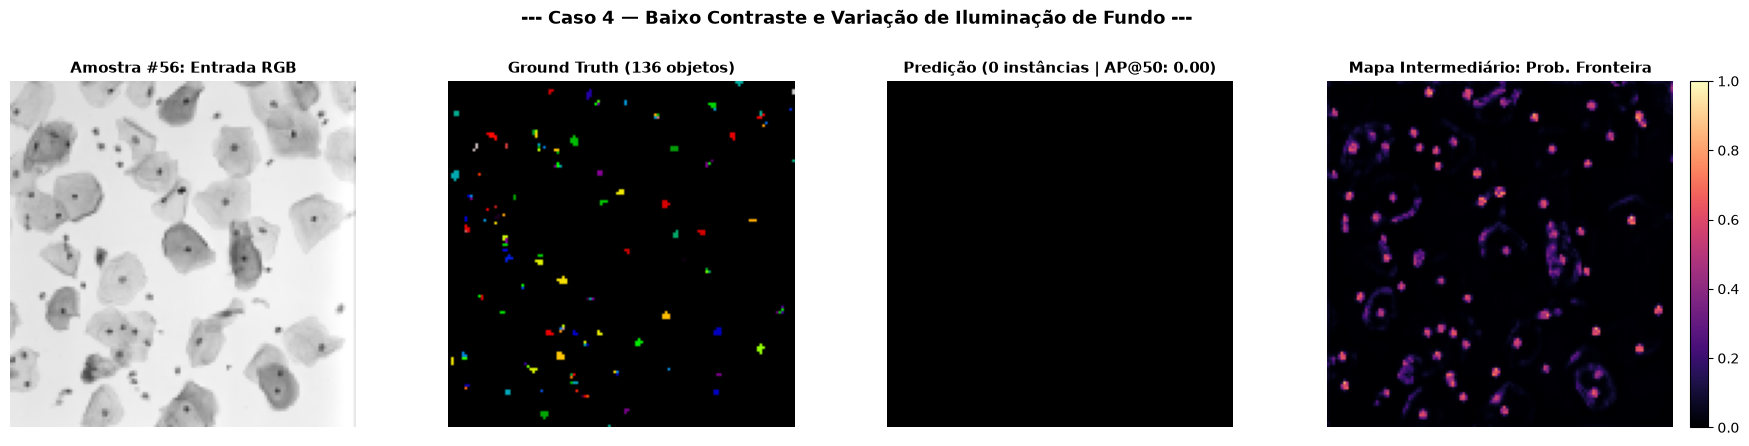

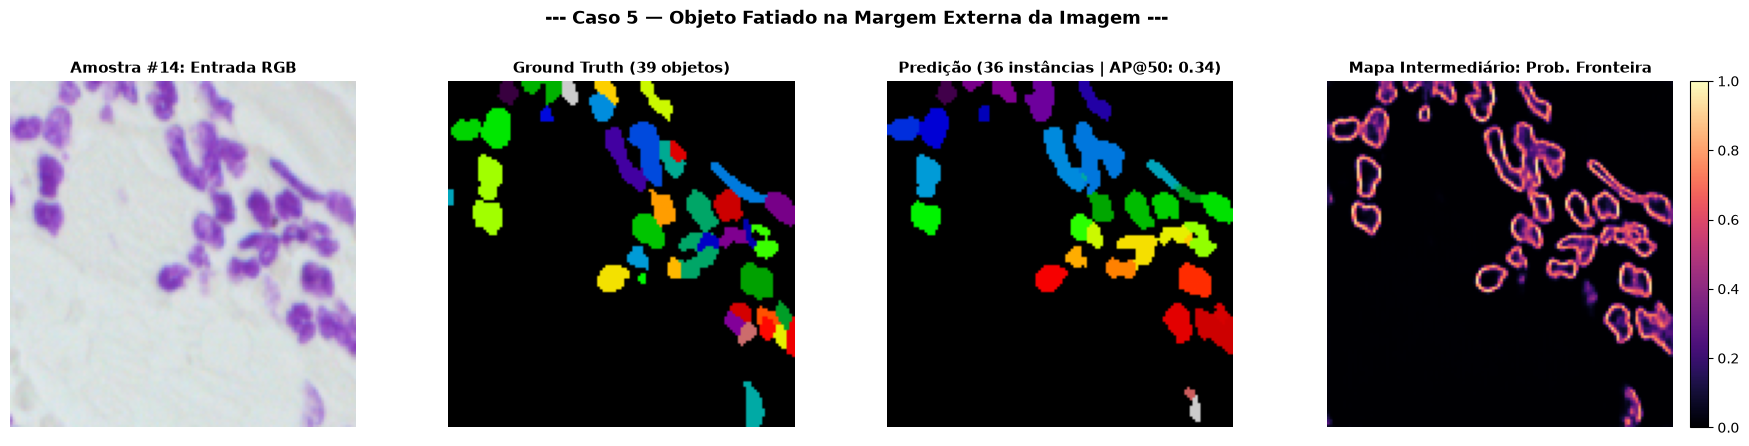

In [44]:
# Parte 5 — 5 Falhas do Modelo Final (Trilha A)
casos_falhas = utils.minerar_5_falhas_estruturais(
    model=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    device=device
)

utils.plot_painel_5_falhas(casos_falhas)


### Parte 5 — Diagnóstico das 5 Falhas Estruturais

*   **Caso 1: Aglomerado de Núcleos Gigantes (Campo Receptivo Insuficiente)**
  
    **Problema:** O tamanho e alongamento dos objetos ($d_{eq} > 31$ px) excedem a capacidade do campo receptivo local da rede ($\approx 43$ px). Como resultado, a rede perde o contexto local nas regiões de contato e falha em gerar gradientes para as fronteiras internas entre células adjacentes. Isso faz com que o algoritmo de pós-processamento funda múltiplas instâncias em uma única máscara gigante (subsegmentação).
    
    **Correção:** Aplicação da Transformada de Distância Euclidiana (EDT) sobre a máscara global (sem depender apenas do mapa de bordas da rede) para isolar os centros de massa topológicos de cada núcleo, utilizando-os como novos marcadores (*seeds*) para forçar a separação (Watershed) das instâncias colapsadas.

*   **Caso 2: Aglomerado de Células Minúsculas**
  
    **Problema:** Dezenas de núcleos muito pequenos ($d_{eq} \approx 2.3$ px) estão separados por fronteiras extremamente finas. A rede prediz bordas espessas que "vazam" sobre o interior das células adjacentes, o que suprime os marcadores e funde dezenas de instâncias em uma única máscara.

*   **Caso 3: Estrutura em Anel (Centro Oco)**
  
    **Problema:** Um arranjo circular de 250 células minúsculas com o centro vazio. A rede detecta a borda externa contínua do anel ($P(\text{borda}) > 0.70$), mas falha ao mapear as fronteiras internas. Como resultado, o algoritmo Watershed padrão fatia a estrutura inteira em blocos gigantes.
    
    **Correção:** Uso de detecção adaptativa de picos de fluorescência (`peak_local_max`) ao longo do anel para orientar um Watershed de alta resolução, permitindo isolar as células individuais.

*   **Caso 4: Baixo Contraste e Artefatos de Fundo**
  
    **Problema:** Variações na iluminação e ilhas citoplasmáticas difusas geram falsos positivos nos mapas de borda e interior em regiões vazias, resultando na criação de instâncias "fantasmas".

*   **Caso 5: Objeto Cortado na Borda da Imagem**
  
    **Problema:** Núcleos divididos pelos limites da imagem perdem o contexto de suas bordas originais. O uso de *zero-padding* nas convoluções distorce os gradientes locais, o que impede a rede de detectar e delinear corretamente esses fragmentos marginais.


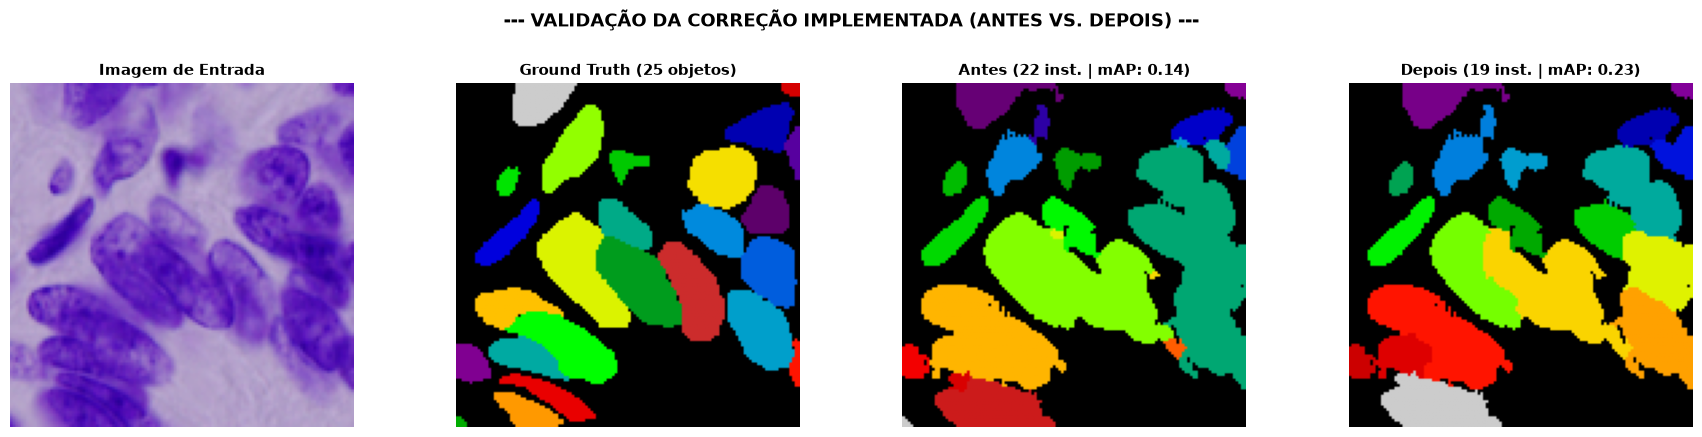

   RESULTADOS DA CORREÇÃO: SUPRESSÃO ADAPTATIVA DE MARCADORES
Métrica                 | Antes da Correção | Depois da Correção | Ganho
------------------------------------------------------------------------
mAP@[.50:.95]           | 0.1430            | 0.2314             | +0.0884
AP @ IoU=0.50           | 0.3056            | 0.5714             | +0.2659
AP @ IoU=0.75           | 0.0930            | 0.1000             | +0.0070
Instâncias Preditas     | 22                | 19                 | -3
Ground Truth (Real)     | 25                | 25                 | --
Erro de Contagem        | 3                 | 6                  | +3


In [45]:
# Parte 5 — Correção 1: Supressão Adaptativa de Marcadores (Núcleo Gigante - Amostra #74)
idx_caso_correcao_1 = casos_falhas[0]["idx"]
resultado_correcao_1 = utils.avaliar_e_plotar_correcao(
    model=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    caso_idx=idx_caso_correcao_1,
    device=device,
    min_distance=8
)

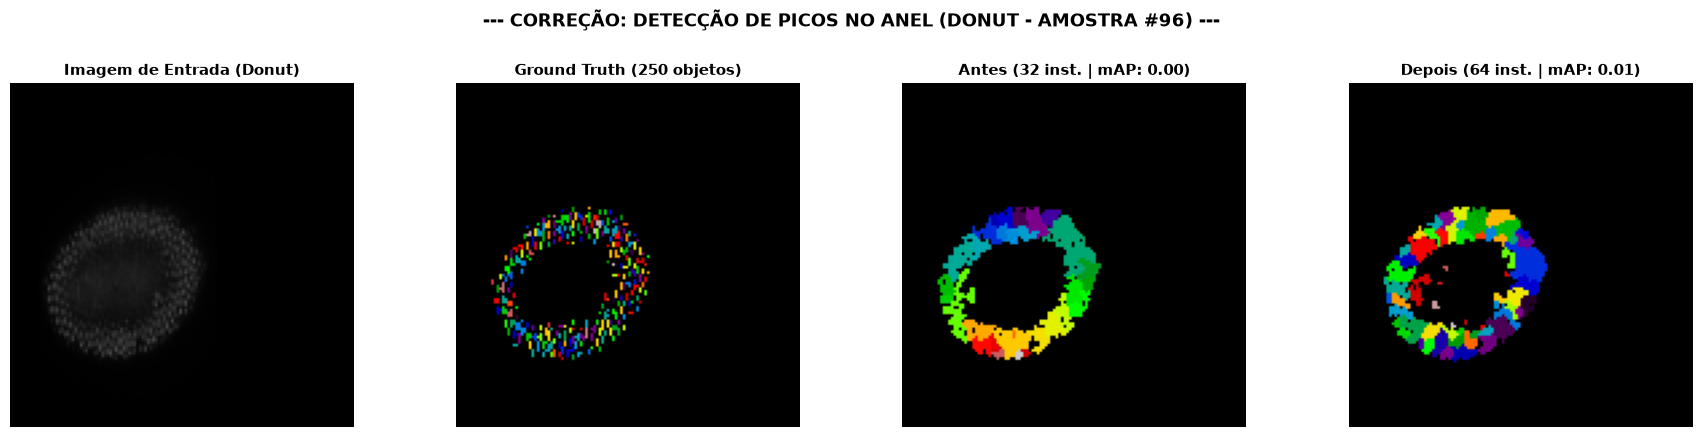

   RESULTADOS: RECUPERAÇÃO DE SEMENTES NO ANEL (DONUT - AMOSTRA #96)
Métrica                 | Antes da Correção | Depois da Correção | Ganho
------------------------------------------------------------------------
mAP@[.50:.95]           | 0.0000            | 0.0061             | +0.0061
AP @ IoU=0.50           | 0.0000            | 0.0129             | +0.0129
AP @ IoU=0.75           | 0.0000            | 0.0032             | +0.0032
Instâncias Preditas     | 32                | 64                 | +32
Ground Truth (Real)     | 250               | 250                | --
Erro de Contagem        | 218               | 186                | -32


In [46]:
# Parte 5 — Correção 2: Detecção de Picos de Fluorescência no Anel (Donut - Amostra #96)
idx_caso_correcao_2 = casos_falhas[2]["idx"]
resultado_correcao_2 = utils.avaliar_e_plotar_correcao_donut(
    model=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    caso_idx=idx_caso_correcao_2,
    device=device,
    min_distance=2,
    threshold_rel=0.10
)

---
# Parte 6 — Teste de Estresse

**Teste escolhido:**

Mudança de modalidade

In [47]:
# Parte 6 (Item 1) — Isolamento Estratificado das Modalidades (Treino sem "brightfield_color")
X_tr_fluo, y_tr_fluo, y_tr_3c_fluo = utils.filtrar_por_modalidade(
    X_tr_r, y_tr_r, y_tr_3c, modalidade="fluorescence", excluir=False
)
X_v_fluo, y_v_fluo, y_v_3c_fluo = utils.filtrar_por_modalidade(
    X_v_r, y_v_r, y_v_3c, modalidade="fluorescence", excluir=False
)

print(f"Treino In-Domain (Fluorescência): {X_tr_fluo.shape[0]} amostras")
print(f"Validação In-Domain (Fluorescência): {X_v_fluo.shape[0]} amostras")
print("Modalidade Omitida para Teste de Estresse: 'brightfield_color' (Campo Claro / Histologia)")

Treino In-Domain (Fluorescência): 382 amostras
Validação In-Domain (Fluorescência): 82 amostras
Modalidade Omitida para Teste de Estresse: 'brightfield_color' (Campo Claro / Histologia)


In [48]:
# Parte 6 (Item 2) — Treinamento do Modelo U-Net (Trilha A) Exclusivamente em Fluorescência
model_stress, weights_stress = utils.treinar_modelo_modalidade(
    X_train=X_tr_fluo,
    y_train_3c=y_tr_3c_fluo,
    X_val=X_v_fluo,
    y_val_3c=y_v_3c_fluo,
    device=device,
    num_epochs=15,
    batch_size=16,
    learning_rate=0.0005,
    random_seed=42
)

Iniciando treinamento na modalidade selecionada (382 amostras de treino)...
Epoch [ 1/15] | Train Loss: 0.3532 | Val Loss: 0.3543
Epoch [ 2/15] | Train Loss: 0.2544 | Val Loss: 0.2574
Epoch [ 3/15] | Train Loss: 0.2103 | Val Loss: 0.2021
Epoch [ 4/15] | Train Loss: 0.1804 | Val Loss: 0.1635
Epoch [ 5/15] | Train Loss: 0.1585 | Val Loss: 0.1407
Epoch [ 6/15] | Train Loss: 0.1416 | Val Loss: 0.1273
Epoch [ 7/15] | Train Loss: 0.1282 | Val Loss: 0.1193
Epoch [ 8/15] | Train Loss: 0.1183 | Val Loss: 0.1069
Epoch [ 9/15] | Train Loss: 0.1088 | Val Loss: 0.0993
Epoch [10/15] | Train Loss: 0.1020 | Val Loss: 0.0971
Epoch [11/15] | Train Loss: 0.0956 | Val Loss: 0.0920
Epoch [12/15] | Train Loss: 0.0902 | Val Loss: 0.0914
Epoch [13/15] | Train Loss: 0.0856 | Val Loss: 0.0851
Epoch [14/15] | Train Loss: 0.0817 | Val Loss: 0.0820
Epoch [15/15] | Train Loss: 0.0788 | Val Loss: 0.0922


In [49]:
# Parte 6 (Item 3) — Avaliação Quantitativa sob Mudança de Modalidade (Teste de Estresse)
res_estresse = utils.avaliar_teste_estresse_modalidade(
    model_stress=model_stress,
    model_full=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    device=device,
    mod_treinada="fluorescence",
    mod_estresse="brightfield_color",
    threshold_interior=0.35,
    threshold_fg=0.35,
    matching_method="hungarian"
)

utils.imprimir_tabela_estresse_modalidade(res_estresse)

Avaliando Teste de Estresse:
  - In-Domain (fluorescence): 82 amostras de teste
  - Out-of-Domain / Estresse (brightfield_color): 16 amostras de teste

[1/3] Avaliando Modelo Completo (M_all) na modalidade de estresse...

[2/3] Avaliando Modelo de Estresse (M_stress) no In-Domain...

[3/3] Avaliando Modelo de Estresse (M_stress) na modalidade NÃO VISTA (Estresse)...
                    TABELA DE ESTRESSE: MUDANÇA DE MODALIDADE (fluorescence -> brightfield_color)
Configuração Experimental                    | mAP@[.5:.95] | AP@0.50  | AP@0.75  | Erro Cont.
------------------------------------------------------------------------------------------------
1. M_all (Treinado c/ Todas)  -> Teste brightfield_color | 0.3165       | 0.5618   | 0.3145   | 4.88      
2. M_stress (Treino fluorescence) -> Teste fluorescence | 0.5317       | 0.7805   | 0.5917   | 7.40      
3. M_stress (Treino fluorescence) -> Teste brightfield_color | 0.0007       | 0.0031   | 0.0000   | 9.62      
-> Degradação rel

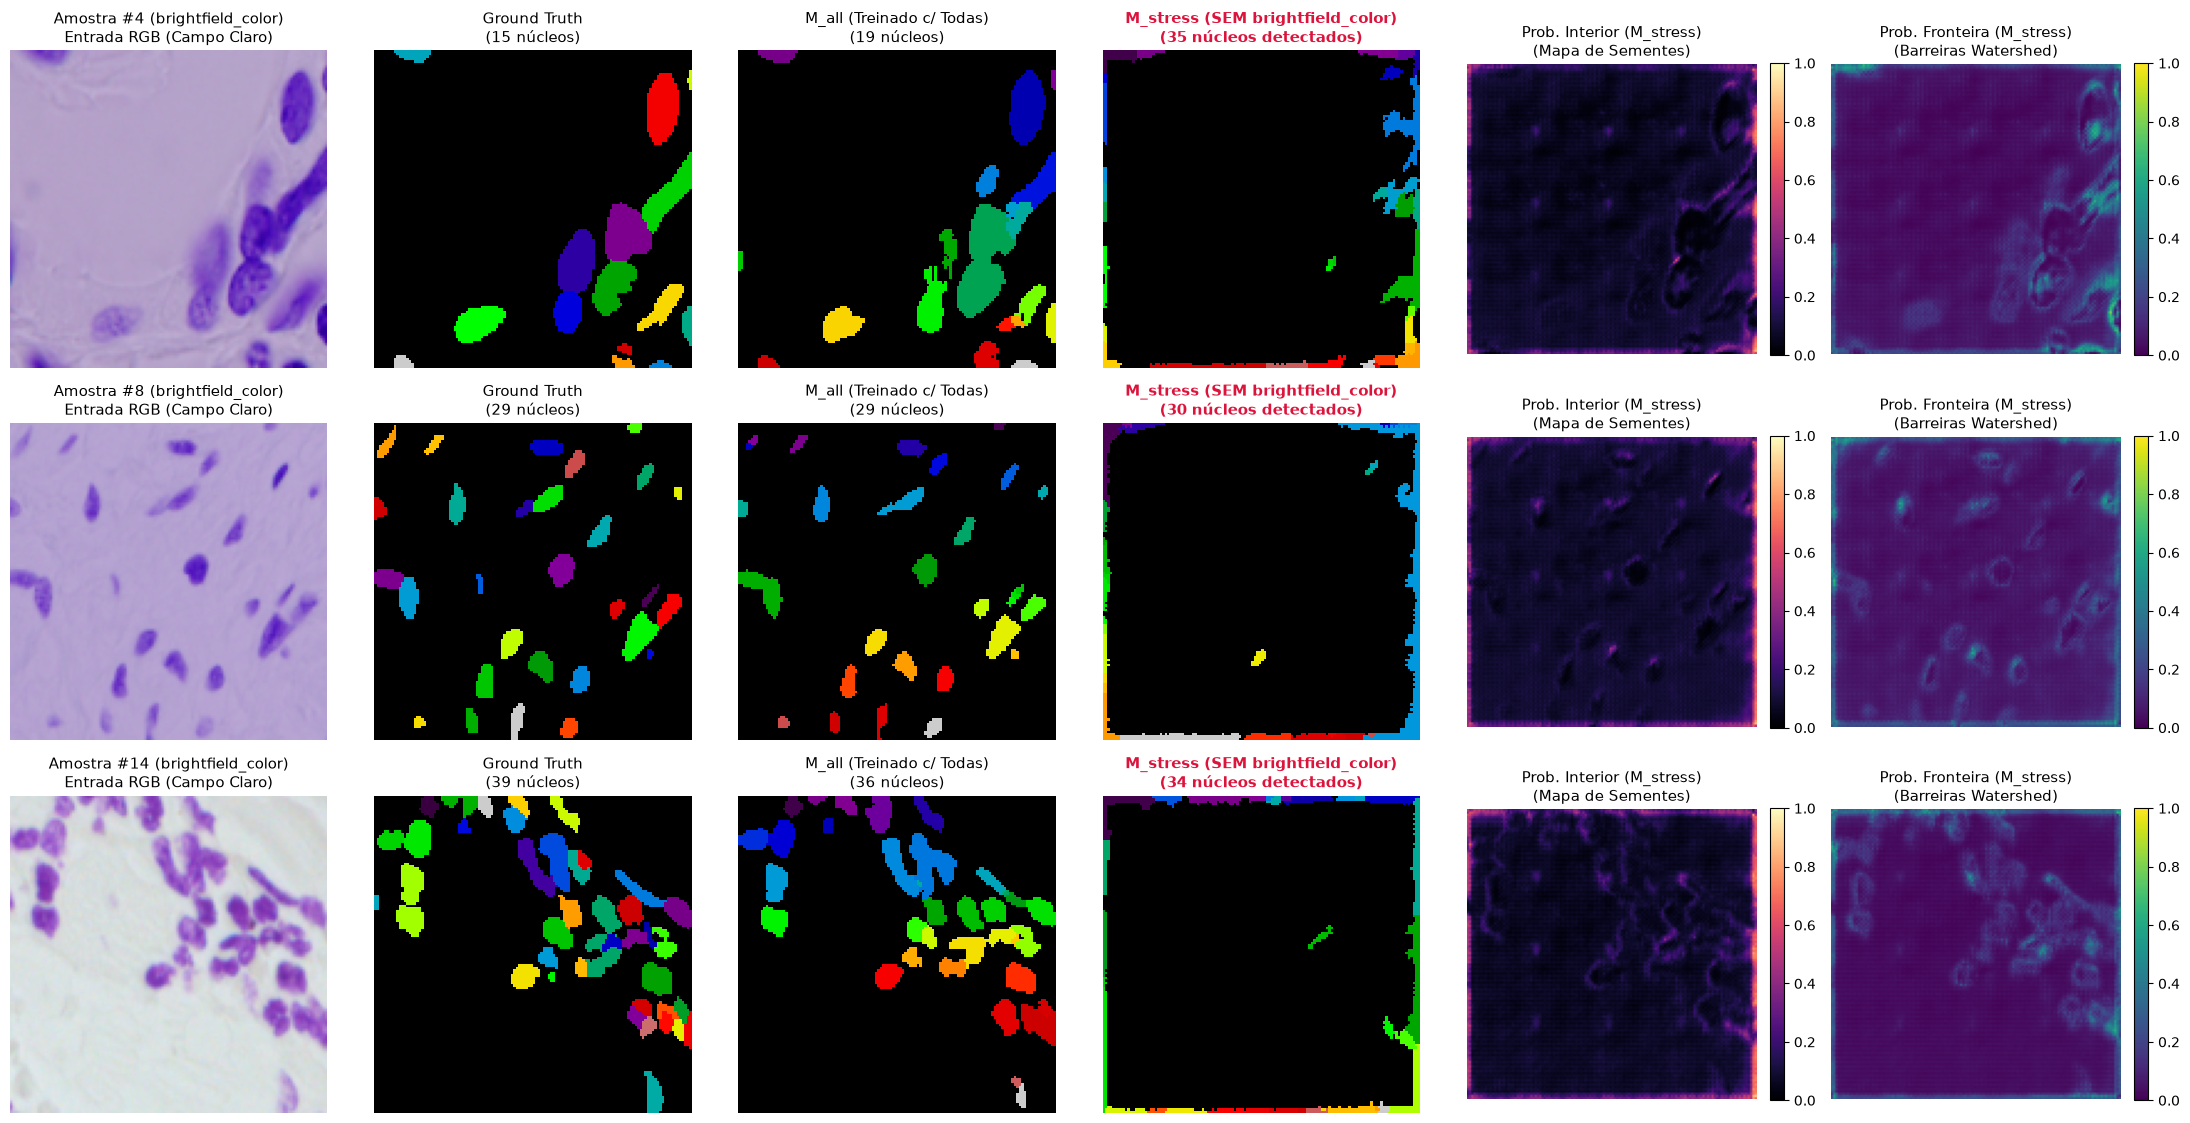

In [50]:
# Parte 6 (Item 4) — Visualização Qualitativa do Fracasso sob Mudança de Modalidade
utils.plot_comparacao_estresse_modalidade(
    model_stress=model_stress,
    model_full=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    device=device,
    mod_estresse="brightfield_color",
    num_samples=3
)

**CÓDIGO PARA SALVAR O MODELO:**

In [51]:
# # Recarrega o módulo utils para importar as novas funções
# import importlib
# import utils
# importlib.reload(utils)

# # Salva o checkpoint com os pesos e metadados de inferência
# caminho_ckpt = utils.salvar_checkpoint(
#     model=model_trilha_a,
#     filepath="checkpoints/checkpoint.pt",
#     threshold_interior=0.35,
#     threshold_fg=0.35
# )